Justificación DE LOS PARAMETROS DE MFCC

El sistema de reconocimiento de emociones utiliza coeficientes MFCC (Mel Frequency Cepstral Coefficients) obtenidos a partir de señales de voz. Para garantizar compatibilidad entre el entrenamiento del modelo en Python y la implementación en ESP32, se definieron los siguientes parámetros.

Frecuencia de muestreo (sr) = 16000 
Tamaño de ventana(n_fft) = 512 
(Hop) = 256 
mel = 20 log natural 
frames = 124 
recorte = 63



In [1]:
import numpy as np
from numpy import array
from numpy import savetxt
import math
from scipy.fft import dct
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix
from sklearn.metrics import precision_recall_fscore_support
from sklearn.metrics import roc_curve, auc, roc_auc_score
import seaborn as sns
import IPython.display as ipd
import librosa
import tensorflow as tf
from tensorflow.keras.regularizers import l2
import pathlib

### Carga Audios

La señal de audio se captura a 16 kHz, lo cual es un estándar en procesamiento de voz.
Justificación:
La voz humana contiene la mayor parte de su energía entre 0 y 8 kHz. 
Según el teorema de Nyquist, para capturar frecuencias hasta 8 kHz se requiere al menos: 
2×8000=16000" Hz"


In [2]:
#Parámetros
sampling_rate = 16000 #4096 antes 
duration = 2

#Calcula número de muestras
num_muestras = sampling_rate*duration
num_muestras

#Vector de clases
clases_vec = [0,1]
emotion_vec = ["Other","Angry"]

In [3]:
#Carga Audios Entrenamiento (English)
#---------------------------------------------------------
#Carpeta con los audios de enojo (Angry)
trainAudioAngryPath = '../Dataset/ESD/Emotional_Speech_Dataset/English/Angry/train'
#Carpeta con los audios de felicidad (Happy)
trainAudioHappyPath = '../Dataset/ESD/Emotional_Speech_Dataset/English/Happy/train'
#Carpeta con los audios neutrales (Neutral)
trainAudioNeutralPath = '../Dataset/ESD/Emotional_Speech_Dataset/English/Neutral/train'
#Carpeta con los audios de tristeza (Sad)
trainAudioSadPath = '../Dataset/ESD/Emotional_Speech_Dataset/English/Sad/train'
#Carpeta con los audios de tristeza (Surprise)
trainAudioSurprisePath = '../Dataset/ESD/Emotional_Speech_Dataset/English/Surprise/train'
#Carga Audios Prueba (English)
#---------------------------------------------------------
#Carpeta con los audios de enojo (Angry)
testAudioAngryPath = '../Dataset/ESD/Emotional_Speech_Dataset/English/Angry/test'
#Carpeta con los audios de felicidad (Happy)
testAudioHappyPath = '../Dataset/ESD/Emotional_Speech_Dataset/English/Happy/test'
#Carpeta con los audios neutrales (Neutral)
testAudioNeutralPath = '../Dataset/ESD/Emotional_Speech_Dataset/English/Neutral/test'
#Carpeta con los audios de tristeza (Sad)
testAudioSadPath = '../Dataset/ESD/Emotional_Speech_Dataset/English/Sad/test'
#Carpeta con los audios de tristeza (Surprise)
testAudioSurprisePath = '../Dataset/ESD/Emotional_Speech_Dataset/English/Surprise/test'
#Carga Audios Evaluación (English)
#---------------------------------------------------------
#Carpeta con los audios de enojo (Angry)
evalAudioAngryPath = '../Dataset/ESD/Emotional_Speech_Dataset/English/Angry/evaluation'
#Carpeta con los audios de felicidad (Happy)
evalAudioHappyPath = '../Dataset/ESD/Emotional_Speech_Dataset/English/Happy/evaluation'
#Carpeta con los audios neutrales (Neutral)
evalAudioNeutralPath = '../Dataset/ESD/Emotional_Speech_Dataset/English/Neutral/evaluation'
#Carpeta con los audios de tristeza (Sad)
evalAudioSadPath = '../Dataset/ESD/Emotional_Speech_Dataset/English/Sad/evaluation'
#Carpeta con los audios de tristeza (Surprise)
evalAudioSurprisePath = '../Dataset/ESD/Emotional_Speech_Dataset/English/Surprise/evaluation'



#Carga Audios Entrenamiento (Chinese)
#---------------------------------------------------------
#Carpeta con los audios de enojo (Angry)
trainAudioAngryPathC = '../Dataset/ESD/Emotional_Speech_Dataset/Chinese/Angry/train'
#Carpeta con los audios de felicidad (Happy)
trainAudioHappyPathC = '../Dataset/ESD/Emotional_Speech_Dataset/Chinese/Happy/train'
#Carpeta con los audios neutrales (Neutral)
trainAudioNeutralPathC = '../Dataset/ESD/Emotional_Speech_Dataset/Chinese/Neutral/train'
#Carpeta con los audios de tristeza (Sad)
trainAudioSadPathC = '../Dataset/ESD/Emotional_Speech_Dataset/Chinese/Sad/train'
#Carpeta con los audios de tristeza (Surprise)
trainAudioSurprisePathC = '../Dataset/ESD/Emotional_Speech_Dataset/Chinese/Surprise/train'
#Carga Audios Prueba (Chinese)
#---------------------------------------------------------
#Carpeta con los audios de enojo (Angry)
testAudioAngryPathC = '../Dataset/ESD/Emotional_Speech_Dataset/Chinese/Angry/test'
#Carpeta con los audios de felicidad (Happy)
testAudioHappyPathC = '../Dataset/ESD/Emotional_Speech_Dataset/Chinese/Happy/test'
#Carpeta con los audios neutrales (Neutral)
testAudioNeutralPathC = '../Dataset/ESD/Emotional_Speech_Dataset/Chinese/Neutral/test'
#Carpeta con los audios de tristeza (Sad)
testAudioSadPathC = '../Dataset/ESD/Emotional_Speech_Dataset/Chinese/Sad/test'
#Carpeta con los audios de tristeza (Surprise)
testAudioSurprisePathC = '../Dataset/ESD/Emotional_Speech_Dataset/Chinese/Surprise/test'
#Carga Audios Evaluación (Chinese)
#---------------------------------------------------------
#Carpeta con los audios de enojo (Angry)
evalAudioAngryPathC = '../Dataset/ESD/Emotional_Speech_Dataset/Chinese/Angry/evaluation'
#Carpeta con los audios de felicidad (Happy)
evalAudioHappyPathC = '../Dataset/ESD/Emotional_Speech_Dataset/Chinese/Happy/evaluation'
#Carpeta con los audios neutrales (Neutral)
evalAudioNeutralPathC = '../Dataset/ESD/Emotional_Speech_Dataset/Chinese/Neutral/evaluation'
#Carpeta con los audios de tristeza (Sad)
evalAudioSadPathC = '../Dataset/ESD/Emotional_Speech_Dataset/Chinese/Sad/evaluation'
#Carpeta con los audios de tristeza (Surprise)
evalAudioSurprisePathC = '../Dataset/ESD/Emotional_Speech_Dataset/Chinese/Surprise/evaluation'

In [4]:
#Función para cargar audios de una carpeta
def loadAudio(pathAudio, label):
    #Encuentra los archivos con extensión .wav y los pone en una lista
    files = librosa.util.find_files(pathAudio, ext=['wav']) 
    #Convierte la lista en un arreglo numpy
    files = np.asarray(files)

    #Crea lista de audios vacía
    Audios = []

    #Lee los audios y los almacena en la lista de audios
    for archivo in files: 
        audio = librosa.load(archivo, sr=sampling_rate, mono=True, duration=duration)
        #calcula espectrograma
        spectrogram = np.abs(librosa.stft(audio[0], n_fft=512, hop_length=256))
        #calcula espectrograma en decibeles 
        spectrogram_db = librosa.amplitude_to_db(spectrogram, ref=np.max)
        
        #Calcula la energía máxima por columna de tiempo
        max_energy = np.empty(spectrogram_db.shape[1])
        for i in range(spectrogram_db.shape[1]):
            max_energy[i] = np.mean(spectrogram_db[:,i])
            
        #Guarda posición inicial de dato de muestro
        for i in range(1, spectrogram_db.shape[1]):
            diff_energy = abs(max_energy[i]-max_energy[i-1])
            if(diff_energy >= 5):
                #Número de columnas
                col = spectrogram_db.shape[1]
                #Muestras por columna
                muesXcol = int(num_muestras/col)
                #Posición inicial
                start_pos = (i * muesXcol)
                break
        
        #Lee audio nuevamente pero agregando 2 segundos
        audio = librosa.load(archivo, sr=sampling_rate, mono=True, duration=duration+2)     
        #Toma 2 segundos de audio a partir de donde empieza el sonido
        new_audio = audio[0][start_pos : start_pos+num_muestras]
        
        Audios.append(new_audio)
    
    #Crea nueva lista de audios con igual dimensiones
    Audios_equal_dim = []
    
    for audio in Audios:
        
        if audio.shape[0]<num_muestras:
            sample = np.append(audio,np.zeros(num_muestras-audio.shape[0]))
        else:
            sample = audio[0:num_muestras]
        
        #Calcula media y desviación estandar
        mean = np.mean(sample)
        sd = np.std(sample)
        #Calcula ruido blanco
        white_noise = np.random.normal(loc = mean, scale = abs(sd/50), size = num_muestras)
        
        #Concatena audio más ruido
        Audios_equal_dim.append(sample+white_noise)
            
    #Regresa audios
    return np.asarray(Audios_equal_dim), np.full(len(Audios), label)

In [5]:
#Carga Audios Entrenamiento
#---------------------------------------------------------
trainAudiosAngry, trainLabelAngry = loadAudio(trainAudioAngryPath, clases_vec[1])
trainAudiosAngryC, trainLabelAngryC = loadAudio(trainAudioAngryPathC, clases_vec[1])

trainAudiosHappy, trainLabelHappy = loadAudio(trainAudioHappyPath, clases_vec[0])
trainAudiosHappyC, trainLabelHappyC = loadAudio(trainAudioHappyPathC, clases_vec[0])
trainAudiosNeutral, trainLabelNeutral = loadAudio(trainAudioNeutralPath, clases_vec[0])
trainAudiosNeutralC, trainLabelNeutralC = loadAudio(trainAudioNeutralPathC, clases_vec[0])
trainAudiosSad, trainLabelSad = loadAudio(trainAudioSadPath, clases_vec[0])
trainAudiosSadC, trainLabelSadC = loadAudio(trainAudioSadPathC, clases_vec[0])
trainAudiosSurprise, trainLabelSurprise = loadAudio(trainAudioSurprisePath, clases_vec[0])
trainAudiosSurpriseC, trainLabelSurpriseC = loadAudio(trainAudioSurprisePathC, clases_vec[0])

#Carga Audios Prueba
#---------------------------------------------------------
testAudiosAngry, testLabelAngry = loadAudio(testAudioAngryPath, clases_vec[1])
testAudiosAngryC, testLabelAngryC = loadAudio(testAudioAngryPathC, clases_vec[1])

testAudiosHappy, testLabelHappy = loadAudio(testAudioHappyPath, clases_vec[0])
testAudiosHappyC, testLabelHappyC = loadAudio(testAudioHappyPathC, clases_vec[0])
testAudiosNeutral, testLabelNeutral = loadAudio(testAudioNeutralPath, clases_vec[0])
testAudiosNeutralC, testLabelNeutralC = loadAudio(testAudioNeutralPathC, clases_vec[0])
testAudiosSad, testLabelSad = loadAudio(testAudioSadPath, clases_vec[0])
testAudiosSadC, testLabelSadC = loadAudio(testAudioSadPathC, clases_vec[0])
testAudiosSurprise, testLabelSurprise = loadAudio(testAudioSurprisePath, clases_vec[0])
testAudiosSurpriseC, testLabelSurpriseC = loadAudio(testAudioSurprisePathC, clases_vec[0])

#Carga Audios Evaluación
#---------------------------------------------------------
evalAudiosAngry, evalLabelAngry = loadAudio(evalAudioAngryPath, clases_vec[1])
evalAudiosAngryC, evalLabelAngryC = loadAudio(evalAudioAngryPathC, clases_vec[1])

evalAudiosHappy, evalLabelHappy = loadAudio(evalAudioHappyPath, clases_vec[0])
evalAudiosHappyC, evalLabelHappyC = loadAudio(evalAudioHappyPathC, clases_vec[0])
evalAudiosNeutral, evalLabelNeutral = loadAudio(evalAudioNeutralPath, clases_vec[0])
evalAudiosNeutralC, evalLabelNeutralC = loadAudio(evalAudioNeutralPathC, clases_vec[0])
evalAudiosSad, evalLabelSad = loadAudio(evalAudioSadPath, clases_vec[0])
evalAudiosSadC, evalLabelSadC = loadAudio(evalAudioSadPathC, clases_vec[0])
evalAudiosSurprise, evalLabelSurprise = loadAudio(evalAudioSurprisePath, clases_vec[0])
evalAudiosSurpriseC, evalLabelSurpriseC = loadAudio(evalAudioSurprisePathC, clases_vec[0])

In [6]:
#Resumen de datos de entrenamiento
#---------------------------------------------------------
print('Audios de entrenamiento:')
print('Número de audios de enojo:\t', trainAudiosAngry.shape, "Etiqueta: ", trainLabelAngry[0])
print('Número de audios de enojoC:\t', trainAudiosAngryC.shape, "Etiqueta: ", trainLabelAngryC[0])
print('Total audios enojo: ',trainAudiosAngry.shape[0]+trainAudiosAngryC.shape[0])
print("\n")
print('Número de audios de felicidad:\t', trainAudiosHappy.shape, "Etiqueta: ", trainLabelHappy[0])
print('Número de audios de felicidadC:\t', trainAudiosHappyC.shape, "Etiqueta: ", trainLabelHappyC[0])
print('Número de audios neutrales:\t', trainAudiosNeutral.shape, "Etiqueta: ", trainLabelNeutral[0])
print('Número de audios neutralesC:\t', trainAudiosNeutralC.shape, "Etiqueta: ", trainLabelNeutralC[0])
print('Número de audios de tristeza:\t', trainAudiosSad.shape, "Etiqueta: ", trainLabelSad[0])
print('Número de audios de tristezaC:\t', trainAudiosSadC.shape, "Etiqueta: ", trainLabelSadC[0])
print('Número de audios de sorpresa:\t', trainAudiosSurprise.shape, "Etiqueta: ", trainLabelSurprise[0])
print('Número de audios de sorpresaC:\t', trainAudiosSurpriseC.shape, "Etiqueta: ", trainLabelSurpriseC[0])
#Resumen de datos de entrenamiento
#---------------------------------------------------------
print('\nAudios de prueba:')
print('Número de audios de enojo:\t', testAudiosAngry.shape, "Etiqueta: ", testLabelAngry[0])
print('Número de audios de enojoC:\t', testAudiosAngryC.shape, "Etiqueta: ", testLabelAngryC[0])
print('Total audios enojo: ',testAudiosAngry.shape[0]+testAudiosAngryC.shape[0])
print("\n")
print('Número de audios de felicidad:\t', testAudiosHappy.shape, "Etiqueta: ", testLabelHappy[0])
print('Número de audios de felicidadC:\t', testAudiosHappyC.shape, "Etiqueta: ", testLabelHappyC[0])
print('Número de audios neutrales:\t', testAudiosNeutral.shape, "Etiqueta: ", testLabelNeutral[0])
print('Número de audios neutralesC:\t', testAudiosNeutralC.shape, "Etiqueta: ", testLabelNeutralC[0])
print('Número de audios de tristeza:\t', testAudiosSad.shape, "Etiqueta: ", testLabelSad[0])
print('Número de audios de tristezaC:\t', testAudiosSadC.shape, "Etiqueta: ", testLabelSadC[0])
print('Número de audios de sorpresa:\t', testAudiosSurprise.shape, "Etiqueta: ", testLabelSurprise[0])
print('Número de audios de sorpresaC:\t', testAudiosSurpriseC.shape, "Etiqueta: ", testLabelSurpriseC[0])

#Resumen de datos de entrenamiento
#---------------------------------------------------------
print('\nAudios de evaluación:')
print('Número de audios de enojo:\t', evalAudiosAngry.shape, "Etiqueta: ", evalLabelAngry[0])
print('Número de audios de enojoC:\t', evalAudiosAngryC.shape, "Etiqueta: ", evalLabelAngryC[0])
print('Total audios enojo: ',evalAudiosAngry.shape[0]+evalAudiosAngryC.shape[0])
print("\n")
print('Número de audios de felicidad:\t', evalAudiosHappy.shape, "Etiqueta: ", evalLabelHappy[0])
print('Número de audios de felicidadC:\t', evalAudiosHappyC.shape, "Etiqueta: ", evalLabelHappyC[0])
print('Número de audios neutrales:\t', evalAudiosNeutral.shape, "Etiqueta: ", evalLabelNeutral[0])
print('Número de audios neutralesC:\t', evalAudiosNeutralC.shape, "Etiqueta: ", evalLabelNeutralC[0])
print('Número de audios de tristeza:\t', evalAudiosSad.shape, "Etiqueta: ", evalLabelSad[0])
print('Número de audios de tristezaC:\t', evalAudiosSadC.shape, "Etiqueta: ", evalLabelSadC[0])
print('Número de audios de sorpresa:\t', evalAudiosSurprise.shape, "Etiqueta: ", evalLabelSurprise[0])
print('Número de audios de sorpresaC:\t', evalAudiosSurpriseC.shape, "Etiqueta: ", evalLabelSurpriseC[0])

Audios de entrenamiento:
Número de audios de enojo:	 (3000, 32000) Etiqueta:  1
Número de audios de enojoC:	 (3000, 32000) Etiqueta:  1
Total audios enojo:  6000


Número de audios de felicidad:	 (3000, 32000) Etiqueta:  0
Número de audios de felicidadC:	 (3008, 32000) Etiqueta:  0
Número de audios neutrales:	 (3000, 32000) Etiqueta:  0
Número de audios neutralesC:	 (3000, 32000) Etiqueta:  0
Número de audios de tristeza:	 (3000, 32000) Etiqueta:  0
Número de audios de tristezaC:	 (3000, 32000) Etiqueta:  0
Número de audios de sorpresa:	 (3001, 32000) Etiqueta:  0
Número de audios de sorpresaC:	 (3000, 32000) Etiqueta:  0

Audios de prueba:
Número de audios de enojo:	 (300, 32000) Etiqueta:  1
Número de audios de enojoC:	 (300, 32000) Etiqueta:  1
Total audios enojo:  600


Número de audios de felicidad:	 (300, 32000) Etiqueta:  0
Número de audios de felicidadC:	 (300, 32000) Etiqueta:  0
Número de audios neutrales:	 (300, 32000) Etiqueta:  0
Número de audios neutralesC:	 (300, 32000) 

### Prepara audios y etiquetas

In [7]:
#Función para elegir cierto número de muestras de audio y etiquetas aleatoriamente
def random_samples(num_index, num_total, audios, labels):
    random_index = np.random.choice(num_index, num_total//8, replace=False)
    random_audios = audios[random_index]
    random_labels = labels[random_index]
    return random_audios, random_labels

In [8]:
#Numero total de audios de enojo en entrenamiento, prueba y evaluación 
num_aud_angry_train = trainAudiosAngry.shape[0]+trainAudiosAngryC.shape[0]
num_aud_angry_test = testAudiosAngry.shape[0]+testAudiosAngryC.shape[0]
num_aud_angry_eval = evalAudiosAngry.shape[0]+evalAudiosAngryC.shape[0]

#Toma aleatoriamente "num_audios_angry_train" muestras para cada emoción distinta al enojo
trainAudiosHappy, trainLabelHappy = random_samples(trainAudiosHappy.shape[0], num_aud_angry_train, trainAudiosHappy, trainLabelHappy)
trainAudiosHappyC, trainLabelHappyC = random_samples(trainAudiosHappyC.shape[0], num_aud_angry_train, trainAudiosHappyC, trainLabelHappyC)
trainAudiosNeutral, trainLabelNeutral = random_samples(trainAudiosNeutral.shape[0], num_aud_angry_train, trainAudiosNeutral, trainLabelNeutral)
trainAudiosNeutralC, trainLabelNeutralC = random_samples(trainAudiosNeutralC.shape[0], num_aud_angry_train, trainAudiosNeutralC, trainLabelNeutralC)
trainAudiosSad, trainLabelSad = random_samples(trainAudiosSad.shape[0], num_aud_angry_train, trainAudiosSad, trainLabelSad)
trainAudiosSadC, trainLabelSadC = random_samples(trainAudiosSadC.shape[0], num_aud_angry_train, trainAudiosSadC, trainLabelSadC)
trainAudiosSurprise, trainLabelSurprise = random_samples(trainAudiosSurprise.shape[0], num_aud_angry_train, trainAudiosSurprise, trainLabelSurprise)
trainAudiosSurpriseC, trainLabelSurpriseC = random_samples(trainAudiosSurpriseC.shape[0], num_aud_angry_train, trainAudiosSurpriseC, trainLabelSurpriseC)

#Toma aleatoriamente "num_audios_angry_test" muestras para cada emoción distinta al enojo
testAudiosHappy, testLabelHappy = random_samples(testAudiosHappy.shape[0], num_aud_angry_test, testAudiosHappy, testLabelHappy)
testAudiosHappyC, testLabelHappyC = random_samples(testAudiosHappyC.shape[0], num_aud_angry_test, testAudiosHappyC, testLabelHappyC)
testAudiosNeutral, testLabelNeutral = random_samples(testAudiosNeutral.shape[0], num_aud_angry_test, testAudiosNeutral, testLabelNeutral)
testAudiosNeutralC, testLabelNeutralC = random_samples(testAudiosNeutralC.shape[0], num_aud_angry_test, testAudiosNeutralC, testLabelNeutralC)
testAudiosSad, testLabelSad = random_samples(testAudiosSad.shape[0], num_aud_angry_test, testAudiosSad, testLabelSad)
testAudiosSadC, testLabelSadC = random_samples(testAudiosSadC.shape[0], num_aud_angry_test, testAudiosSadC, testLabelSadC)
testAudiosSurprise, testLabelSurprise = random_samples(testAudiosSurprise.shape[0], num_aud_angry_test, testAudiosSurprise, testLabelSurprise)
testAudiosSurpriseC, testLabelSurpriseC = random_samples(testAudiosSurpriseC.shape[0], num_aud_angry_test, testAudiosSurpriseC, testLabelSurpriseC)

#Toma aleatoriamente "num_audios_angry_eval" muestras para cada emoción distinta al enojo
evalAudiosHappy, evalLabelHappy = random_samples(evalAudiosHappy.shape[0], num_aud_angry_eval, evalAudiosHappy, evalLabelHappy)
evalAudiosHappyC, evalLabelHappyC = random_samples(evalAudiosHappyC.shape[0], num_aud_angry_eval, evalAudiosHappyC, evalLabelHappyC)
evalAudiosNeutral, evalLabelNeutral = random_samples(evalAudiosNeutral.shape[0], num_aud_angry_eval, evalAudiosNeutral, evalLabelNeutral)
evalAudiosNeutralC, evalLabelNeutralC = random_samples(evalAudiosNeutralC.shape[0], num_aud_angry_eval, evalAudiosNeutralC, evalLabelNeutralC)
evalAudiosSad, evalLabelSad = random_samples(evalAudiosSad.shape[0], num_aud_angry_eval, evalAudiosSad, evalLabelSad)
evalAudiosSadC, evalLabelSadC = random_samples(evalAudiosSadC.shape[0], num_aud_angry_eval, evalAudiosSadC, evalLabelSadC)
evalAudiosSurprise, evalLabelSurprise = random_samples(evalAudiosSurprise.shape[0], num_aud_angry_eval, evalAudiosSurprise, evalLabelSurprise)
evalAudiosSurpriseC, evalLabelSurpriseC = random_samples(evalAudiosSurpriseC.shape[0], num_aud_angry_eval, evalAudiosSurpriseC, evalLabelSurpriseC)

In [9]:
#Función para concatenar audios y etiquetas
def concatenaAudios(audio1, audio2, label1, label2):
    audio1 = np.concatenate([audio1, audio2])
    label1 = np.concatenate([label1, label2])
    return audio1, label1

In [10]:
#Concatena audios y etiquetas de entrenamiento
#---------------------------------------------------------
trainAudios, trainLabels = concatenaAudios(trainAudiosAngry, trainAudiosAngryC, trainLabelAngry, trainLabelAngryC)
trainAudios, trainLabels = concatenaAudios(trainAudios, trainAudiosHappy, trainLabels, trainLabelHappy)
trainAudios, trainLabels = concatenaAudios(trainAudios, trainAudiosHappyC, trainLabels, trainLabelHappyC)
trainAudios, trainLabels = concatenaAudios(trainAudios, trainAudiosNeutral, trainLabels, trainLabelNeutral)
trainAudios, trainLabels = concatenaAudios(trainAudios, trainAudiosNeutralC, trainLabels, trainLabelNeutralC)
trainAudios, trainLabels = concatenaAudios(trainAudios, trainAudiosSad, trainLabels, trainLabelSad)
trainAudios, trainLabels = concatenaAudios(trainAudios, trainAudiosSadC, trainLabels, trainLabelSadC)
trainAudios, trainLabels = concatenaAudios(trainAudios, trainAudiosSurprise, trainLabels, trainLabelSurprise)
trainAudios, trainLabels = concatenaAudios(trainAudios, trainAudiosSurpriseC, trainLabels, trainLabelSurpriseC)

#Concatena audios y etiquetas de prueba
#---------------------------------------------------------
testAudios, testLabels = concatenaAudios(testAudiosAngry, testAudiosAngryC, testLabelAngry, testLabelAngryC)
testAudios, testLabels = concatenaAudios(testAudios, testAudiosHappy, testLabels, testLabelHappy)
testAudios, testLabels = concatenaAudios(testAudios, testAudiosHappyC, testLabels, testLabelHappyC)
testAudios, testLabels = concatenaAudios(testAudios, testAudiosNeutral, testLabels, testLabelNeutral)
testAudios, testLabels = concatenaAudios(testAudios, testAudiosNeutralC, testLabels, testLabelNeutralC)
testAudios, testLabels = concatenaAudios(testAudios, testAudiosSad, testLabels, testLabelSad)
testAudios, testLabels = concatenaAudios(testAudios, testAudiosSadC, testLabels, testLabelSadC)
testAudios, testLabels = concatenaAudios(testAudios, testAudiosSurprise, testLabels, testLabelSurprise)
testAudios, testLabels = concatenaAudios(testAudios, testAudiosSurpriseC, testLabels, testLabelSurpriseC)

#Concatena audios y etiquetas de evaluación
#---------------------------------------------------------
evalAudios, evalLabels = concatenaAudios(evalAudiosAngry, evalAudiosAngryC, evalLabelAngry, evalLabelAngryC)
evalAudios, evalLabels = concatenaAudios(evalAudios, evalAudiosHappy, evalLabels, evalLabelHappy)
evalAudios, evalLabels = concatenaAudios(evalAudios, evalAudiosHappyC, evalLabels, evalLabelHappyC)
evalAudios, evalLabels = concatenaAudios(evalAudios, evalAudiosNeutral, evalLabels, evalLabelNeutral)
evalAudios, evalLabels = concatenaAudios(evalAudios, evalAudiosNeutralC, evalLabels, evalLabelNeutralC)
evalAudios, evalLabels = concatenaAudios(evalAudios, evalAudiosSad, evalLabels, evalLabelSad)
evalAudios, evalLabels = concatenaAudios(evalAudios, evalAudiosSadC, evalLabels, evalLabelSadC)
evalAudios, evalLabels = concatenaAudios(evalAudios, evalAudiosSurprise, evalLabels, evalLabelSurprise)
evalAudios, evalLabels = concatenaAudios(evalAudios, evalAudiosSurpriseC, evalLabels, evalLabelSurpriseC)

In [11]:
#Resumen de audios
print('Número de audios de entrenamiento: ', trainAudios.shape, "Número de etiquetaa: ", trainLabels.shape)
print('Número de audios de prueba: ', testAudios.shape, "Número de etiqueta: ", testLabels.shape)
print('Número de audios evaluación: ', evalAudios.shape, "Número de etiqueta: ", evalLabels.shape)

Número de audios de entrenamiento:  (12000, 32000) Número de etiquetaa:  (12000,)
Número de audios de prueba:  (1200, 32000) Número de etiqueta:  (1200,)
Número de audios evaluación:  (800, 32000) Número de etiqueta:  (800,)


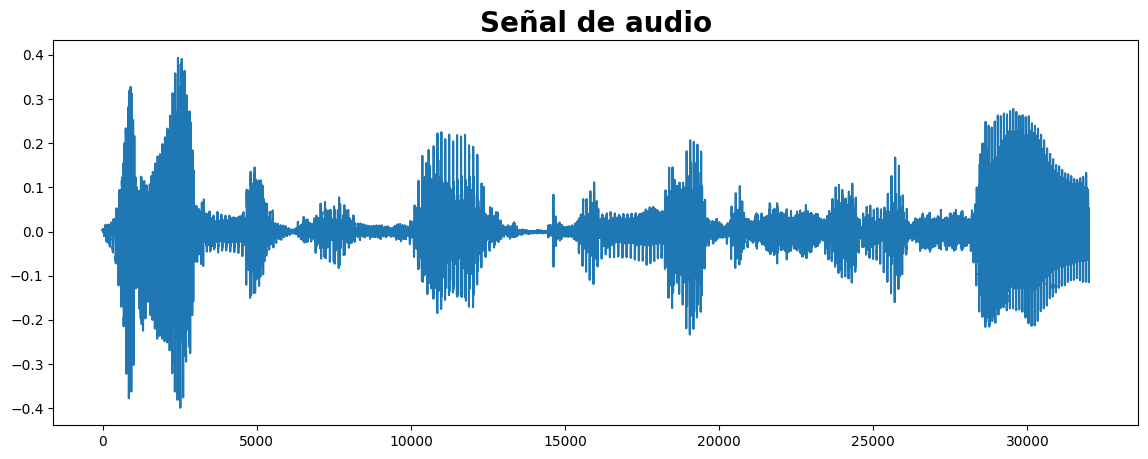

In [12]:
#Prueba
num_audio = 5
#Grafica la señal de primer audio
plt.figure(figsize=(14, 5))
plt.plot(trainAudios[num_audio])
plt.title("Señal de audio", {'fontsize':20, 'fontweight':'bold'})
plt.show()
#Reproduce audio
ipd.Audio(trainAudios[num_audio], rate= sampling_rate)

### Calcula MFCCs

TAMAÑO DE LA VENTANA FFT
-----------------------------------------------------------------

𝑛\_𝑓𝑓𝑡=512

Cada ventana de análisis contiene 512 muestras.

Duración temporal de la ventana:
512/16000=0.032" s"
=32" ms"

Capturan correctamente las características espectrales del habla.



SALTO ENTRE VENTANAS
----------------------------
ℎ𝑜𝑝=256

El salto entre ventanas es de 256 muestras.

Duración temporal:
256/16000=0.016" s"
=16" ms"

Evita pérdida de información entre ventanas


FILTROS DE MEL
-----------------------------------------------------------------
𝑚𝑒𝑙=20
Se utilizan 20 filtros Mel.

Justificación:
La escala Mel aproxima la percepción humana de la frecuencia.


In [13]:
#Parámetros para calcular espectrograma
#-------------------------------------
#Cantidad de datos por audio
Size_data = num_muestras
#Tamaño de la ventana
Size_win = 512 #antes usaba 256   ahora 512 para 25ms de ventana
#Tamaño de offset
Size_off = 256 #antes usaba 128    ahora 256 
#Número total de ventaneos
total_win_num = int(((Size_data-Size_win)/Size_off)+1)
total_win_num

#Parámetros para calcular MFCCs
#------------------------------
#Frecuencia mínima y máxima
frec_min = 20
frec_max = sampling_rate/2
#numero de bandas de Mel
Mel_bands = 20

In [14]:
#Función para calcular un filtro triangular
def triangular_fun(lower_lim, medium_lim, upper_lim, points_num):
    #Crea vector de coeficientes
    coefficients = np.zeros(points_num)
    #Calcula coeficientes
    for j in range(points_num):
        
        if j>=lower_lim and j<=medium_lim:
            coefficients[j] = (j - lower_lim) / (medium_lim - lower_lim)
        elif j>medium_lim and j<=upper_lim:
            coefficients[j] = (upper_lim - j) / (upper_lim - medium_lim)
        else: 
            coefficients[j] = 0
    #Regresa coeficientes
    return coefficients

def triangular_filter_mat(frec_min, frec_max, Mel_bands):
    #numero de límites de bandas
    Mel_num_limits = Mel_bands+2
    #Frecuencia mínima y máxima en Mels
    frec_min_mel = 2595 * np.log10(1 + frec_min / 700)
    frec_max_mel = 2595 * np.log10(1 + frec_max / 700)
    #Tamaño de límite de separación de bandas en Mels
    separation_mel = (frec_max_mel-frec_min_mel)/(Mel_num_limits-1)
    
    #Crea vecor de límites de bandas mel
    mel_limits = np.zeros(Mel_num_limits)
    #Crea vector de límites equidistantes en Mels
    mel_limits[0] = frec_min_mel
    for i in range(1,Mel_num_limits):
        mel_limits[i] = mel_limits[i-1]+separation_mel
    
    #Crea vecor de límites de bandas en Hertz
    Hz_limits = np.zeros(Mel_num_limits)
    #Conversión de límites de Mel a Hertz
    for i in range(Mel_num_limits):
        Hz_limits[i] = 700 * (10**(mel_limits[i]/ 2595) - 1)
        
    #Crea vecor de límites de bandas en FFT bins
    FFT_bins = np.zeros(Mel_num_limits)
    #Cambia valores de frcuencia (Hertz) por valores al FFT bin más cercano, 
    for i in range(Mel_num_limits):
        FFT_bins[i] = math.floor((Size_win//2+1)*Hz_limits[i]/frec_max)
    FFT_bins[Mel_num_limits-1] = Size_win//2
    
    #Define matriz de filtros triangulares
    Trian_mat= np.zeros((Mel_bands, Size_win//2+1))
    #Calula banco de filtros tringulares
    for i in range(2,Mel_num_limits):
        trian_filter = triangular_fun(FFT_bins[i-2], FFT_bins[i-1], FFT_bins[i], Size_win//2+1)
        Trian_mat[i-2,:] = trian_filter
    
    return Trian_mat

#Preénfasis
def preemphasis(signal, coeff=0.97):
    return np.append(signal[0], signal[1:] - coeff * signal[:-1])

#Ventaneo
def windowing(Hamming_window, preemphasized_signal):
    #Define matriz de ventaneos
    Win_mat= np.zeros((Size_win, total_win_num))

    #Ciclo para realizar ventaneo
    cont = 0
    for i in range(total_win_num):
        for j in range(Size_win):
            Win_mat[j][i] = Hamming_window[j]*preemphasized_signal[cont]
            cont = cont+1
        cont = cont-(Size_win-Size_off)
    
    return Win_mat

#fft
def fft_mat(Win_mat):
    #Define matriz de espectrograma
    FFT_mat= np.zeros((1+Size_win//2, total_win_num))
    #Ciclo para realizar FFT por ventana
    for i in range(total_win_num):
        FFT = abs(np.fft.fft(Win_mat[:,i], n = Size_win))
        FFT_mat[:,i] = FFT[0:1+Size_win//2]
    
    return FFT_mat

#Crea ventana Hamming con tamaño Size_win
Hamming_window = np.zeros(Size_win)
for i in range(Size_win):
    Hamming_window[i] = 0.53836-0.46164*(np.cos((2*np.pi*i)/(Size_win-1)));

In [15]:
#Función para calcular MFCCs
def calculoMFCCs(Audios):
    
    number = 1 #Inicializa numero de imagen
    mfccs = [] #Inicializa lista vacía de mfccs
    
    #Caucula Filtros triangulares
    Trian_mat = triangular_filter_mat(frec_min, frec_max, Mel_bands) 
    
    #Ciclo for para calcular MFCCs de cada audio
    for audio in Audios:
        #Espectrograma
        #------------------------------------------------------------------------
        #Preénfasis
        preemphasized_signal = preemphasis(audio)
        #Ventaneo
        Win_mat = windowing(Hamming_window, preemphasized_signal)
        #Fast Fourier Transform (FFT)
        FFT_mat = fft_mat(Win_mat)
        #Aplica banco de filtros triangulares a espectrograma
        Mel_mat = np.dot(Trian_mat, FFT_mat)
        #Aplica transformación logarítmita para escala más adecuada
        Mel_mat_log = np.log(Mel_mat)     #cambio 13*np.log(Mel_mat) para que este igual al mfcc.cpp
        #Aplica transformada de coseno discreta (DCT)
        mfcc = dct(Mel_mat_log, type=2, axis=0, norm='ortho')[:Mel_bands]
     
        #Agrega MFCC resultante a lista
        mfccs.append(mfcc)
        
    return np.asarray(mfccs)

In [16]:
#Caulcula MFCCs de entrenamiento
trainMFCCs = calculoMFCCs(trainAudios)   
#Caulcula MFCCs de prueba
testMFCCs = calculoMFCCs(testAudios)
#Caulcula MFCCs de evaluación
evalMFCCs = calculoMFCCs(evalAudios)

NUMERO DE FRAMES OBTENIDOS
----------------
La señal analizada tiene duración de 2" segundos"

Número de muestras:
16000×2=32000

El número de ventanas se calcula mediante:
𝑓𝑟𝑎𝑚𝑒𝑠=(𝑁−𝑛\_𝑓𝑓𝑡)/ℎ𝑜𝑝+1

donde:

𝑁=32000

Tamaño de ventana (𝑛\_𝑓𝑓𝑡)=512

ℎ𝑜𝑝=256


La red neuronal convolucional fue diseñada para recibir entradas de tamaño de 20×63

Por lo tanto, del MFCC completo:
20×124

se selecciona una ventana central de 63 frames.

El recorte central es una técnica estándar (porque la voz normalmente aparece en el centro del audio)

  0 ---------------------- 124    frames 
  
  30 ---------------------- 92    recorte 
  
 (30 ---------------------- 92)   ventana central


In [17]:
#Dimensiones de MFCCs
print('Las dimenciones de los MFCCs de entrenamiento son:\t', trainMFCCs.shape)
print('Las dimenciones de los MFCCs de prueba son:\t\t', testMFCCs.shape)
print('Las dimenciones de los MFCCs de evaluación son:\t\t', evalMFCCs.shape)

#Valor máximo en el arreglo de MFCCs
print('\nEl valor máximo de los MFCCs son: ', np.amax(trainMFCCs))
#Valor mínimo en el arreglo de MFCCs
print('El valor mínimo de los MFCCs son: ', np.amin(trainMFCCs))

Las dimenciones de los MFCCs de entrenamiento son:	 (12000, 20, 124)
Las dimenciones de los MFCCs de prueba son:		 (1200, 20, 124)
Las dimenciones de los MFCCs de evaluación son:		 (800, 20, 124)

El valor máximo de los MFCCs son:  10.892644588635
El valor mínimo de los MFCCs son:  -23.716546261846208


### Muestra Audios

In [18]:
#Muestra de audio a indicar
num_Audio = 20
AudioSample = trainAudios[num_Audio]

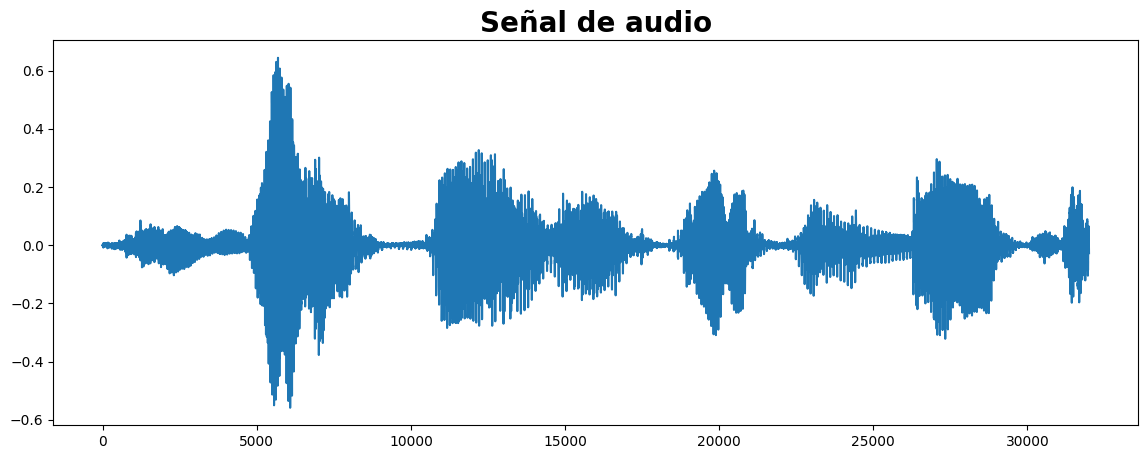

In [19]:
#Grafica la seña de audio elegida
plt.figure(figsize=(14, 5))
plt.plot(AudioSample)
plt.title("Señal de audio", {'fontsize':20, 'fontweight':'bold'})
plt.show()

#Reproduce audio
ipd.Audio(AudioSample, rate= sampling_rate)

(20, 124)


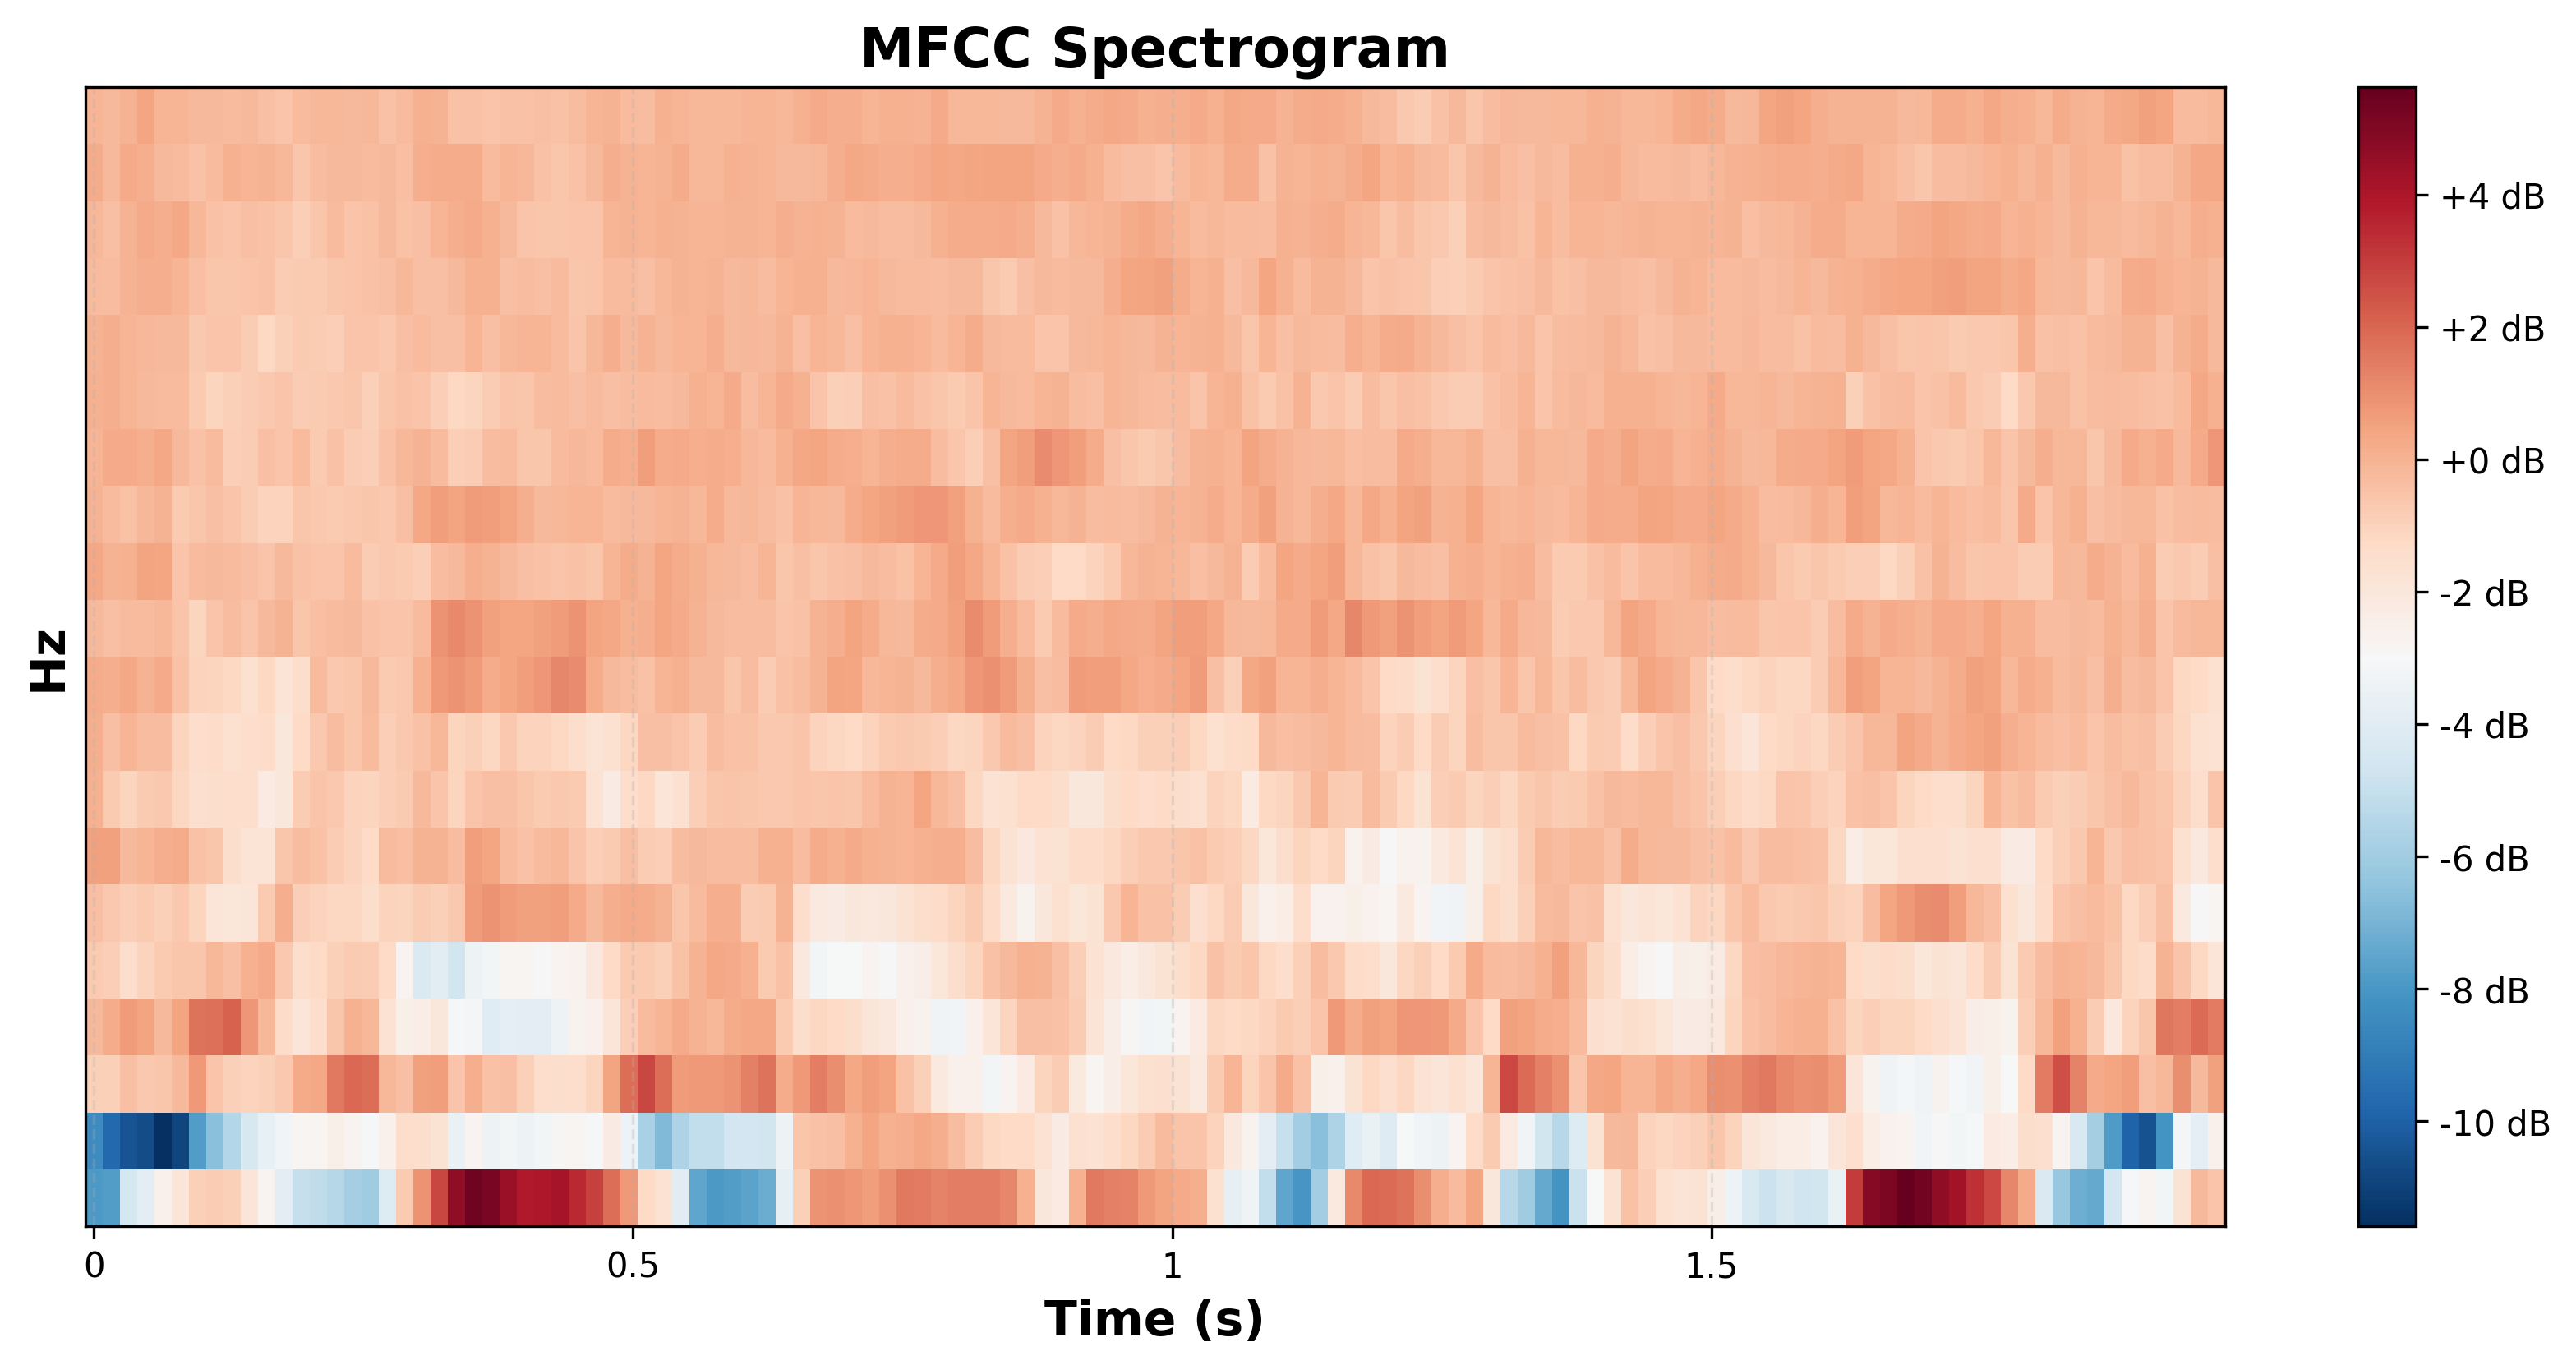

In [20]:
#Muestra MFCC del audio elegido
# Plot the figure
print(trainMFCCs[num_Audio].shape)



# Configuración de la figura con mejor calidad
plt.figure(figsize=(14, 6), dpi=300)
librosa.display.specshow(trainMFCCs[num_Audio], sr=sampling_rate, hop_length=Size_off, x_axis='time', cmap='RdBu_r')  # Rojo a Azul

# Añadir barra de color y mejorar etiquetas
plt.colorbar(format='%+2.0f dB')
plt.xlabel('Time (s)', fontsize=14, fontweight='bold')
plt.ylabel('Hz', fontsize=14, fontweight='bold')
plt.title('MFCC Spectrogram', fontsize=16, fontweight='bold')

# Agregar cuadrícula para mejor visualización
plt.grid(True, linestyle='--', alpha=0.3)

# Mostrar la gráfica mejorada
plt.show()


(20, 124)


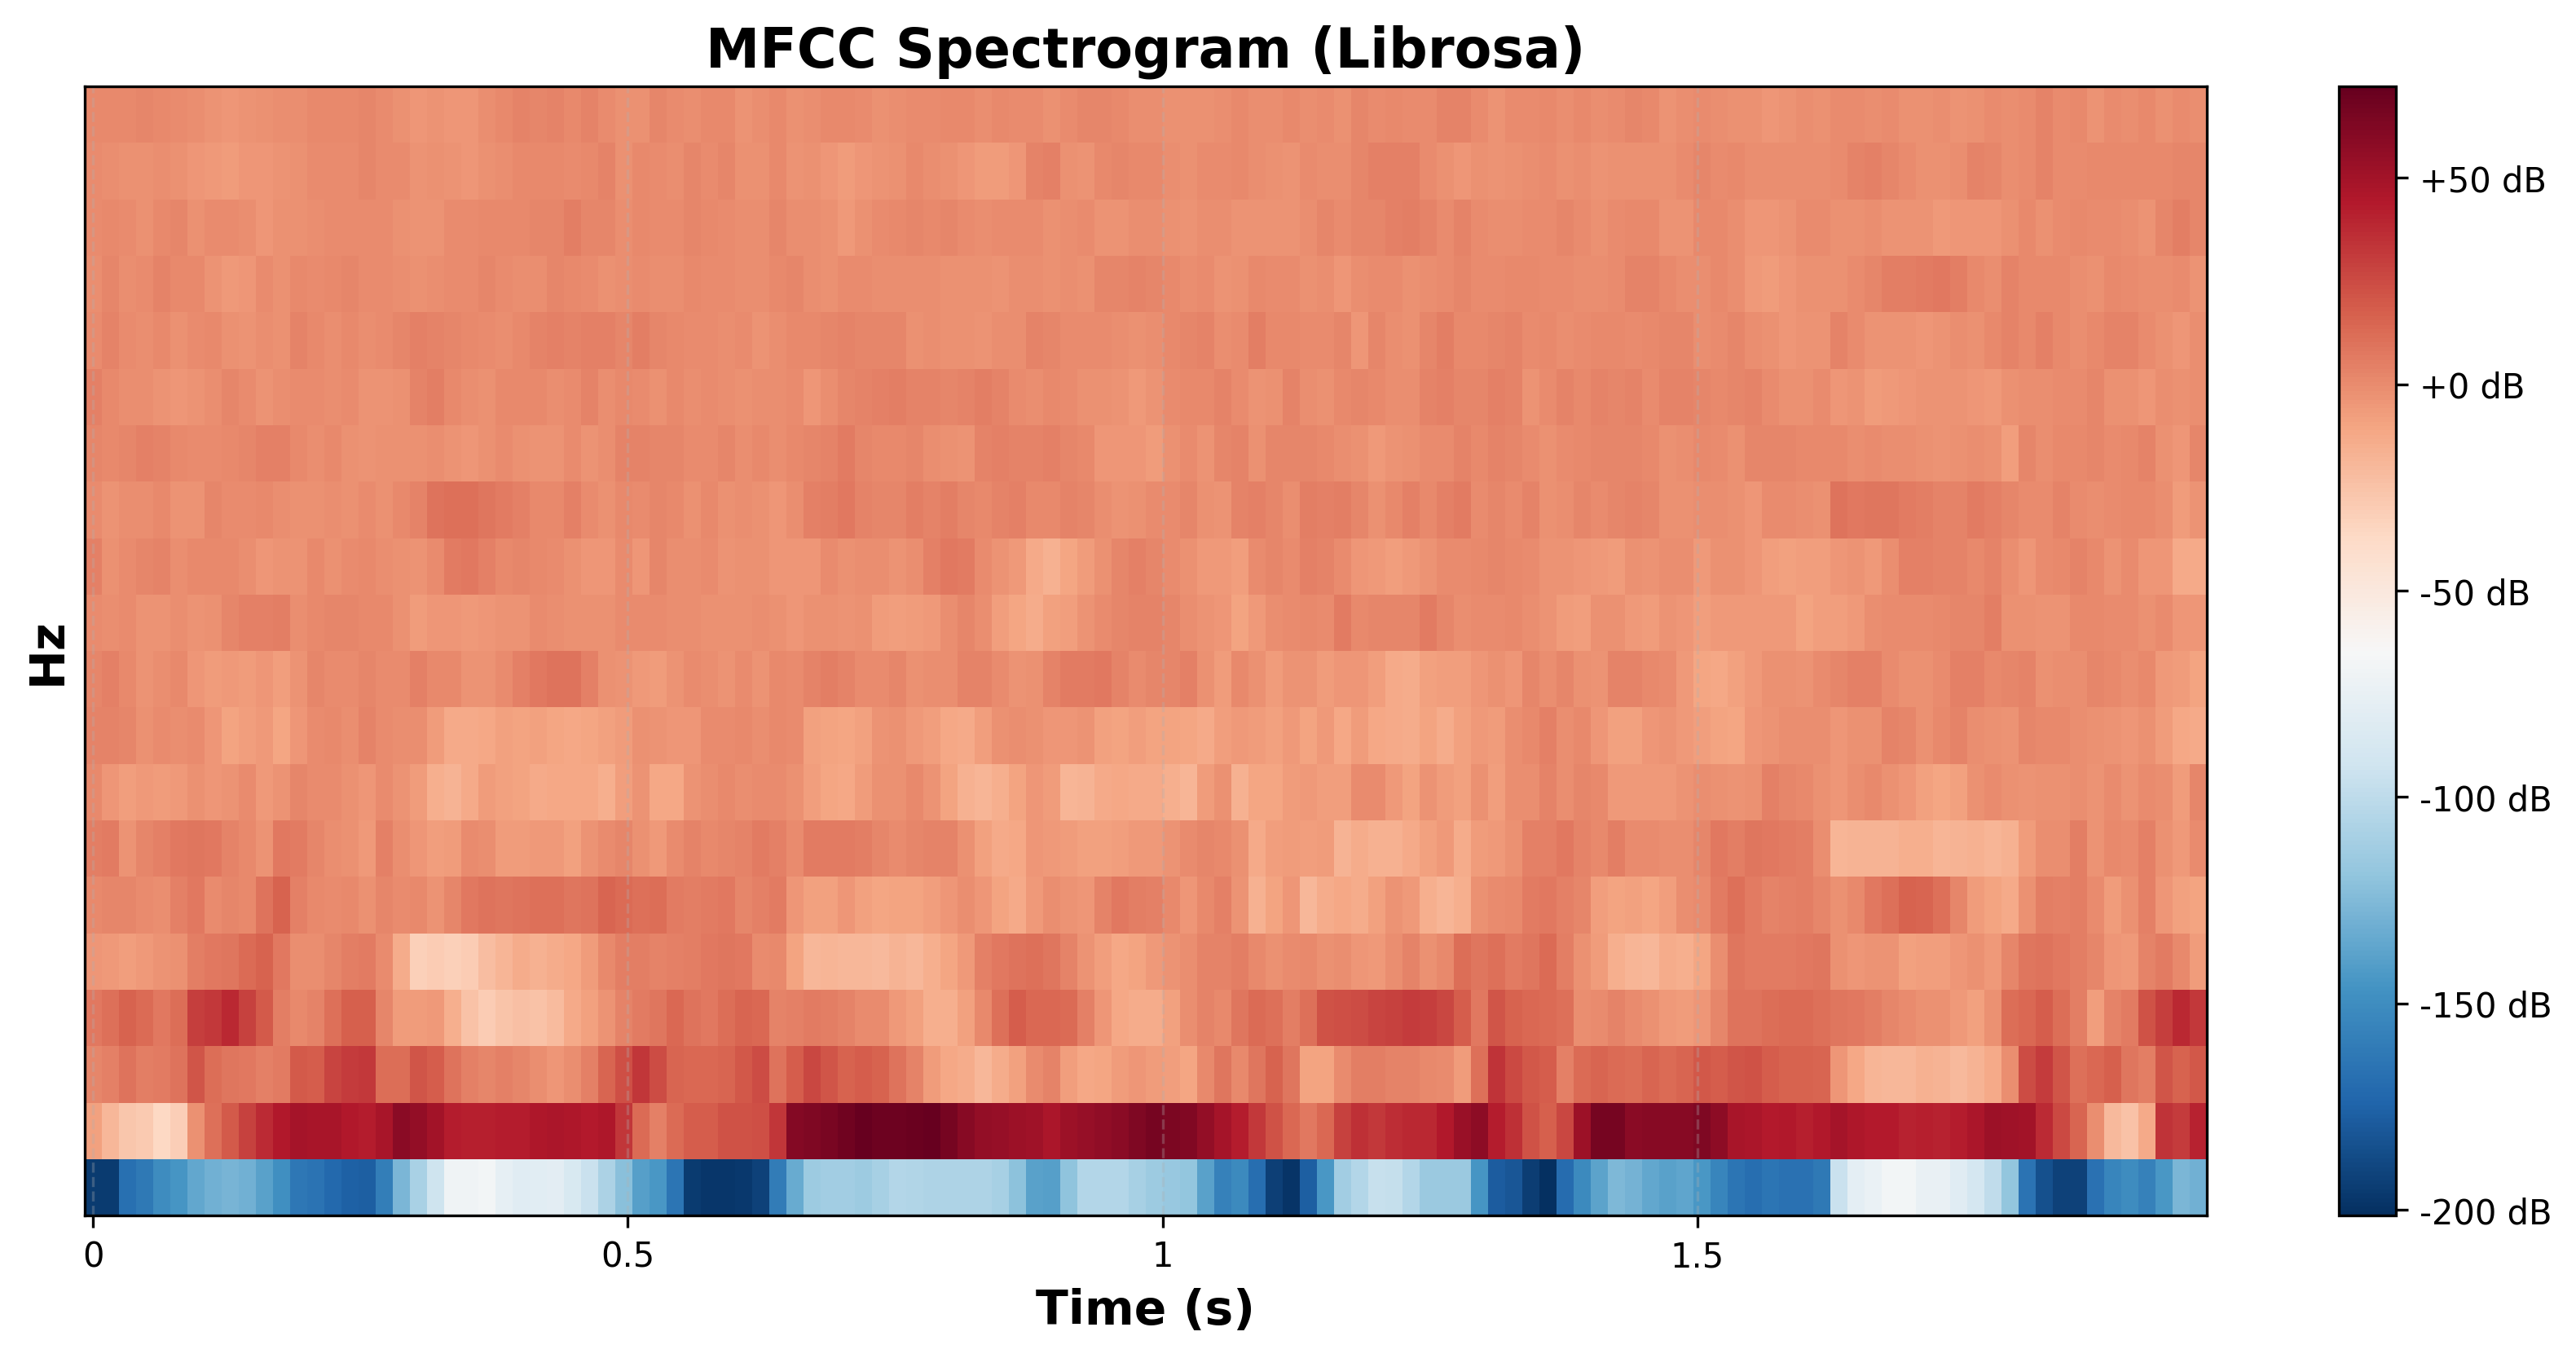

In [21]:
###COMPARATIVA CON LIBROSA###
#Muestra MFCC del audio elegido
mfcc_lib = librosa.feature.mfcc(y=trainAudios[num_Audio], 
                                sr=sampling_rate, 
                                n_mfcc=Mel_bands, 
                                hop_length=Size_off, 
                                n_fft=Size_win,
                                n_mels = Mel_bands,
                               center=False)

print(mfcc_lib.shape)

# Configuración de la figura con mejor calidad
plt.figure(figsize=(14, 6), dpi=300)
librosa.display.specshow(mfcc_lib, sr=sampling_rate, hop_length=Size_off, x_axis='time', cmap='RdBu_r')  # Rojo a Azul

# Añadir barra de color y mejorar etiquetas
plt.colorbar(format='%+2.0f dB')
plt.xlabel('Time (s)', fontsize=14, fontweight='bold')
plt.ylabel('Hz', fontsize=14, fontweight='bold')
plt.title('MFCC Spectrogram (Librosa)', fontsize=16, fontweight='bold')

# Agregar cuadrícula para mejor visualización
plt.grid(True, linestyle='--', alpha=0.3)

# Mostrar la gráfica mejorada
plt.show()

Mfcc vs Librosa
--------------


Se realizó una comparación entre la implementación de MFCC desarrollada en C++ para el microcontrolador y la implementación de referencia utilizando la librería Librosa en Python.

Aunque los valores numéricos no coinciden exactamente debido a diferencias en normalización, generación de filtros Mel y escalamiento logarítmico, los espectrogramas MFCC presentan estructuras temporales y patrones energéticos similares.

Esto confirma que la extracción de características implementada en el sistema embebido reproduce correctamente la información espectral relevante del audio.

Los MFCC no tienen una unidad física directa. Es decir, no están en Hz, segundos, ni dB como tal. Son coeficientes matemáticos adimensionales (sin unidades) que representan la forma del espectro del audio.
-------------------------------------------

Audio: 0
Error promedio((diferencia promedio entre coeficientes MFCC (sin unidades)):  13.52940325952916


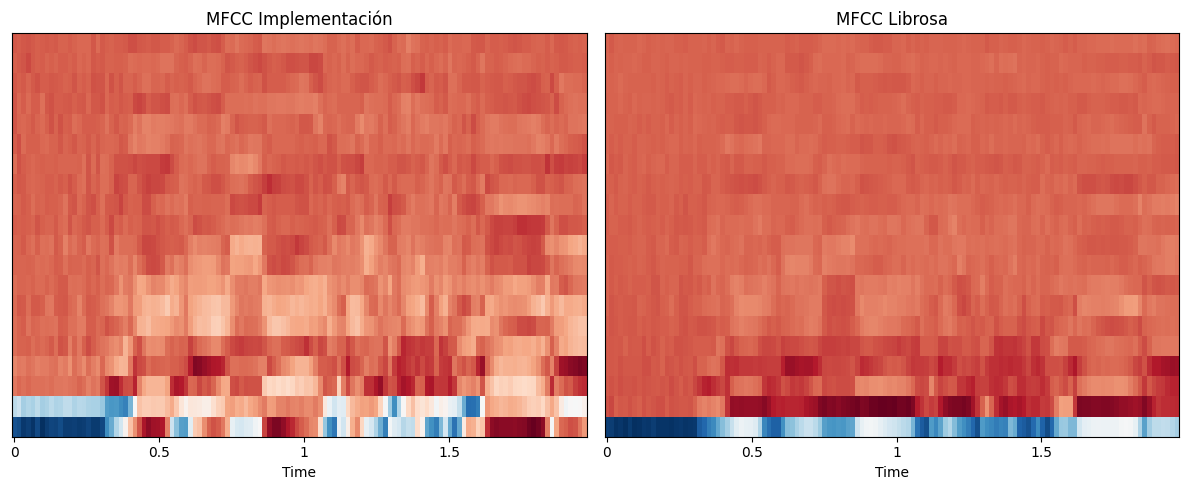

Audio: 1
Error promedio((diferencia promedio entre coeficientes MFCC (sin unidades)):  13.400275604036876


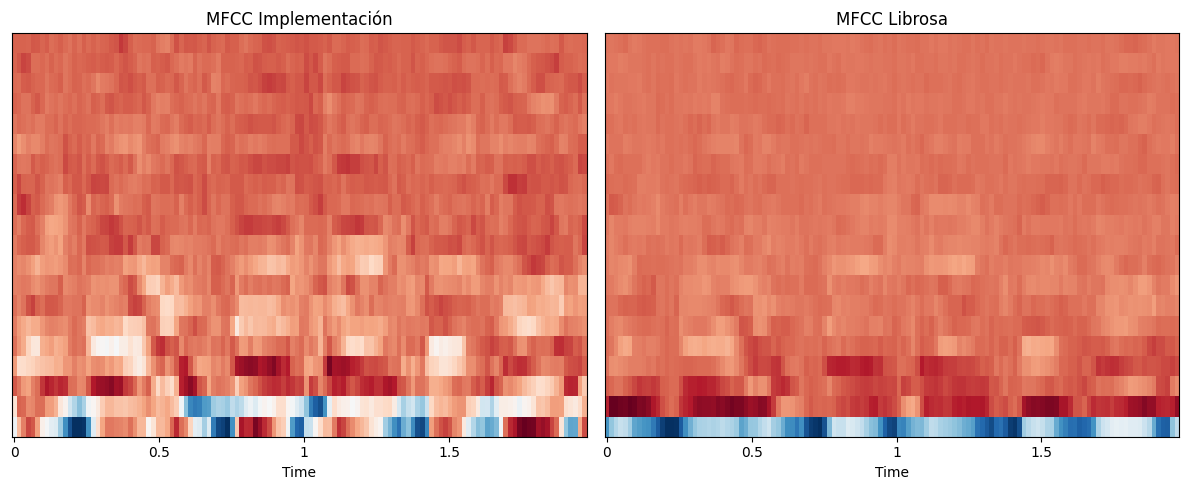

Audio: 2
Error promedio((diferencia promedio entre coeficientes MFCC (sin unidades)):  12.837823031933212


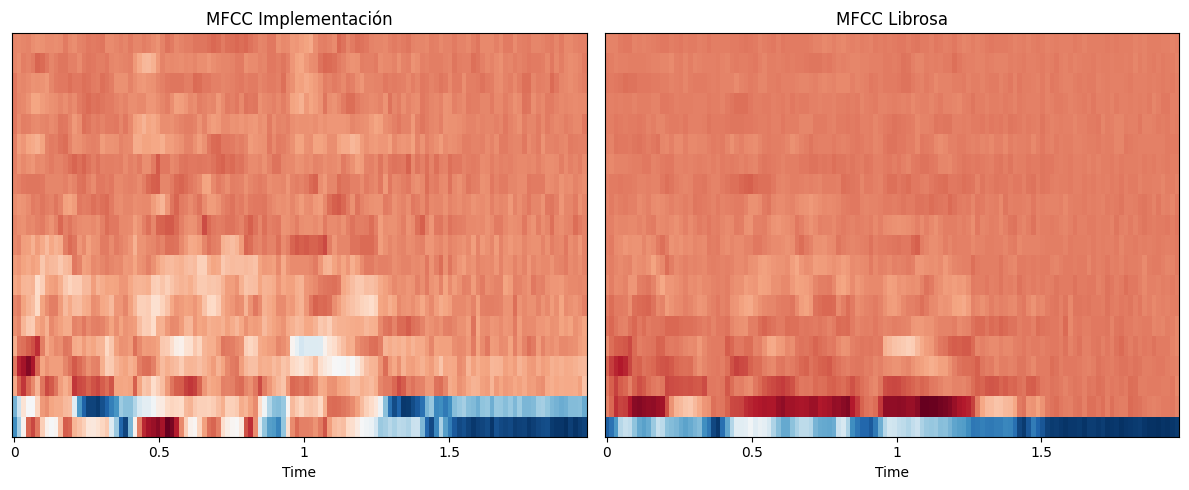

Audio: 3
Error promedio((diferencia promedio entre coeficientes MFCC (sin unidades)):  12.987362054218234


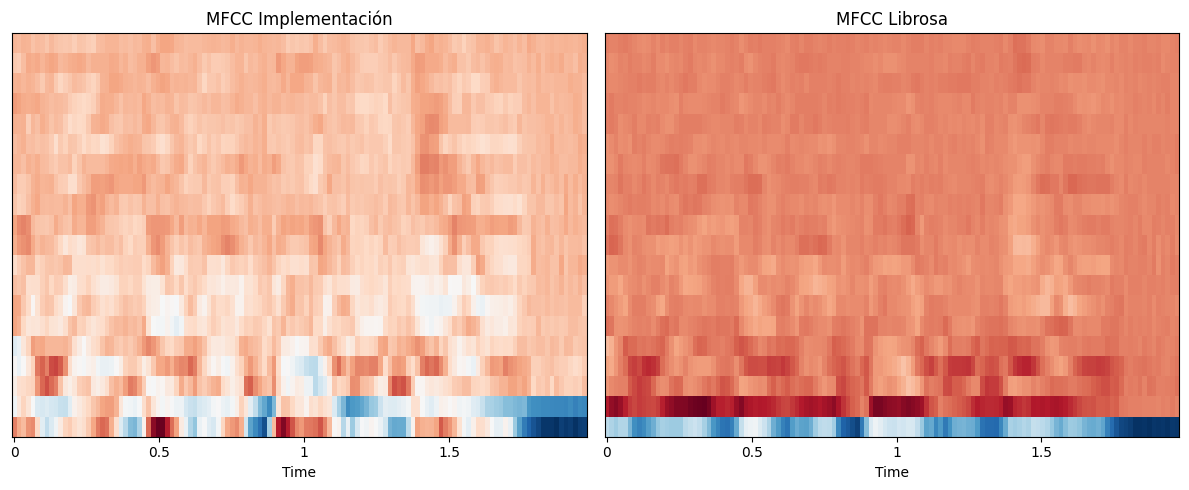

Audio: 4
Error promedio((diferencia promedio entre coeficientes MFCC (sin unidades)):  13.311391472018878


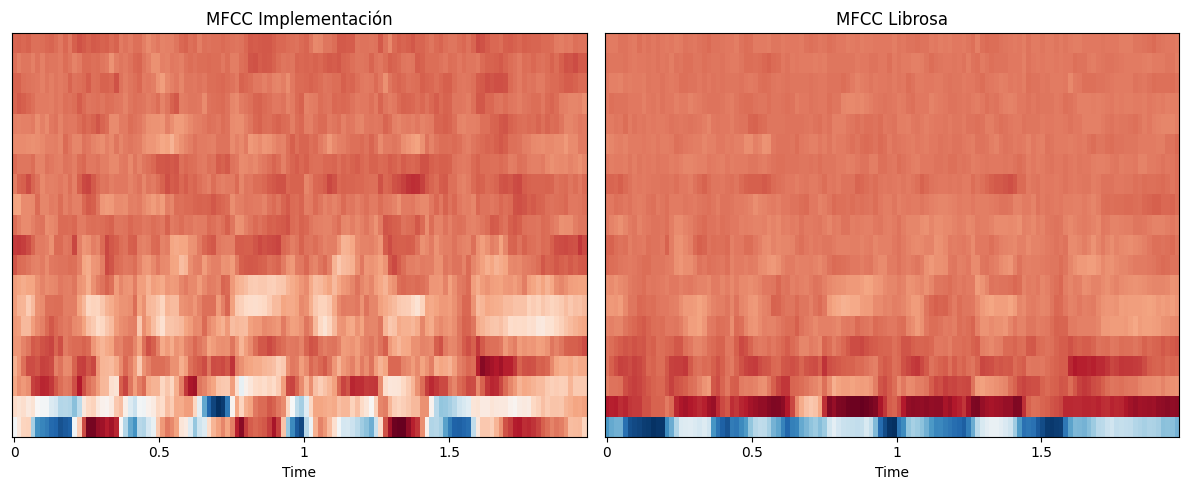

Audio: 5
Error promedio((diferencia promedio entre coeficientes MFCC (sin unidades)):  13.136719187763301


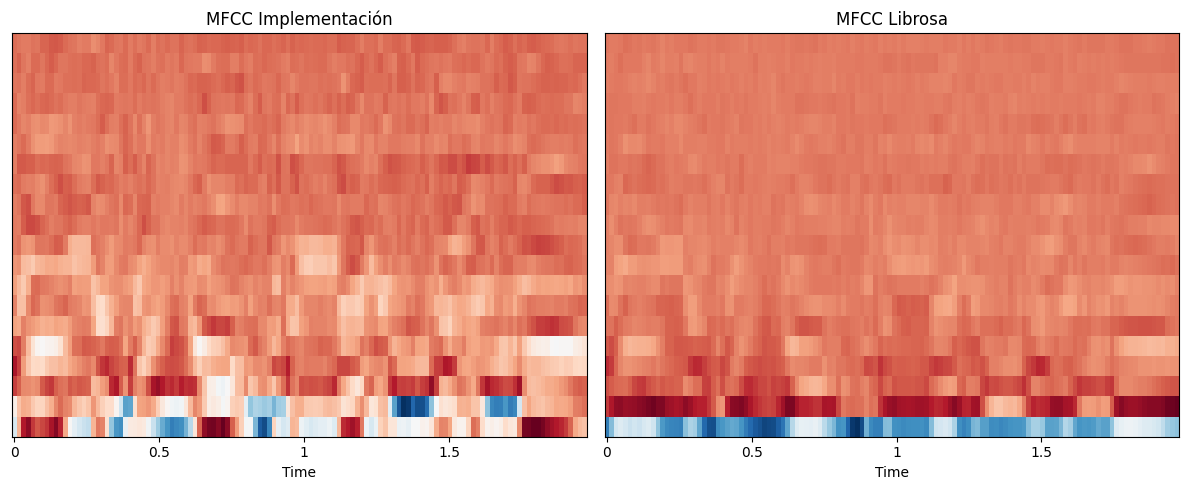

Audio: 6
Error promedio((diferencia promedio entre coeficientes MFCC (sin unidades)):  14.109855268002951


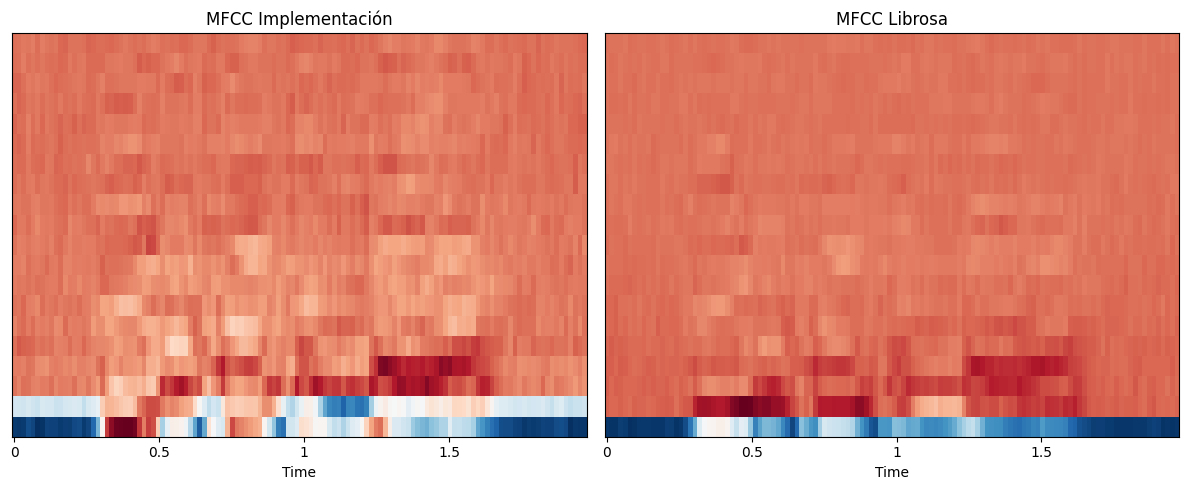

Audio: 7
Error promedio((diferencia promedio entre coeficientes MFCC (sin unidades)):  13.310519168092146


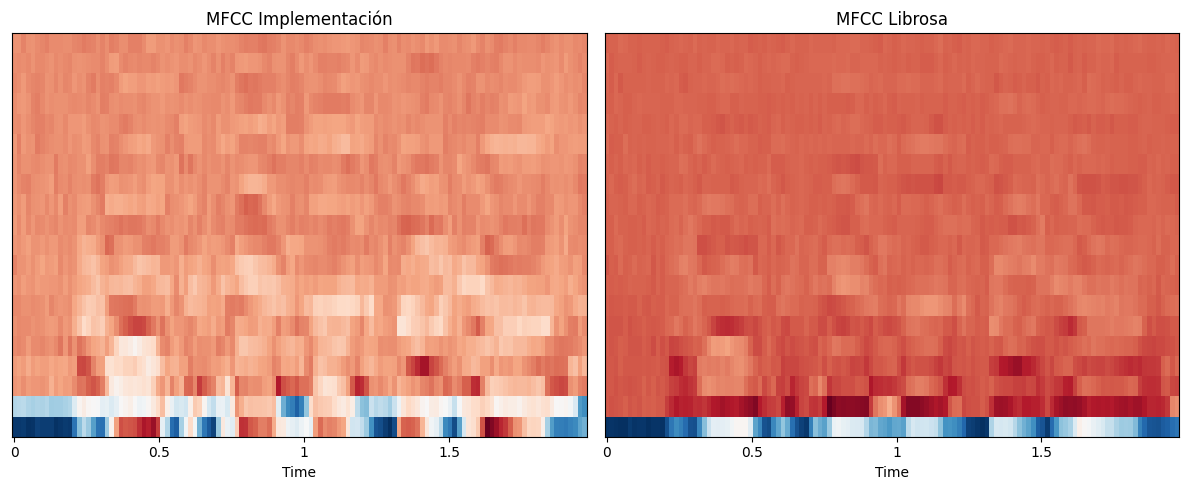

Audio: 8
Error promedio((diferencia promedio entre coeficientes MFCC (sin unidades)):  12.916779711918771


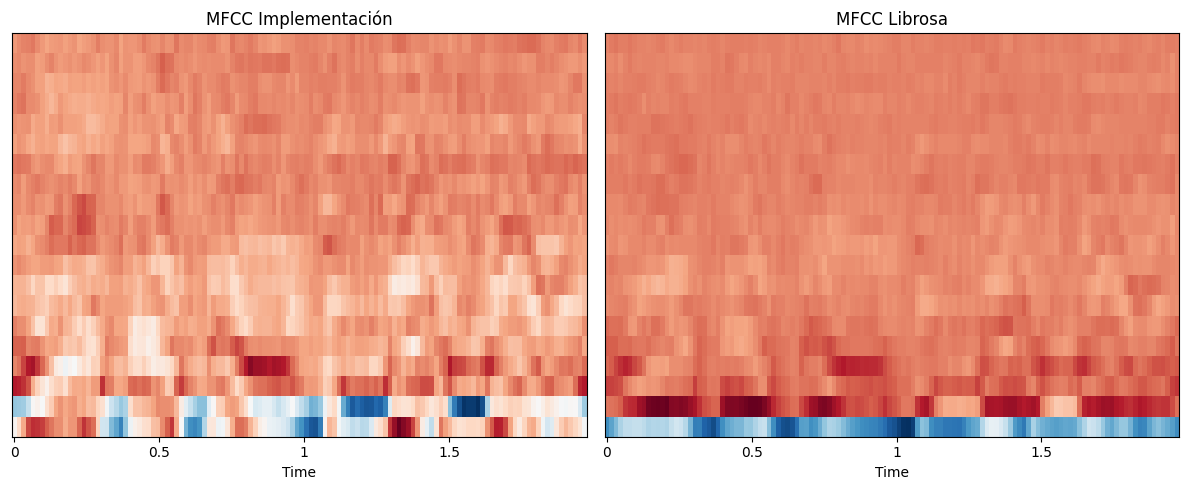

Audio: 9
Error promedio((diferencia promedio entre coeficientes MFCC (sin unidades)):  12.6623691002682


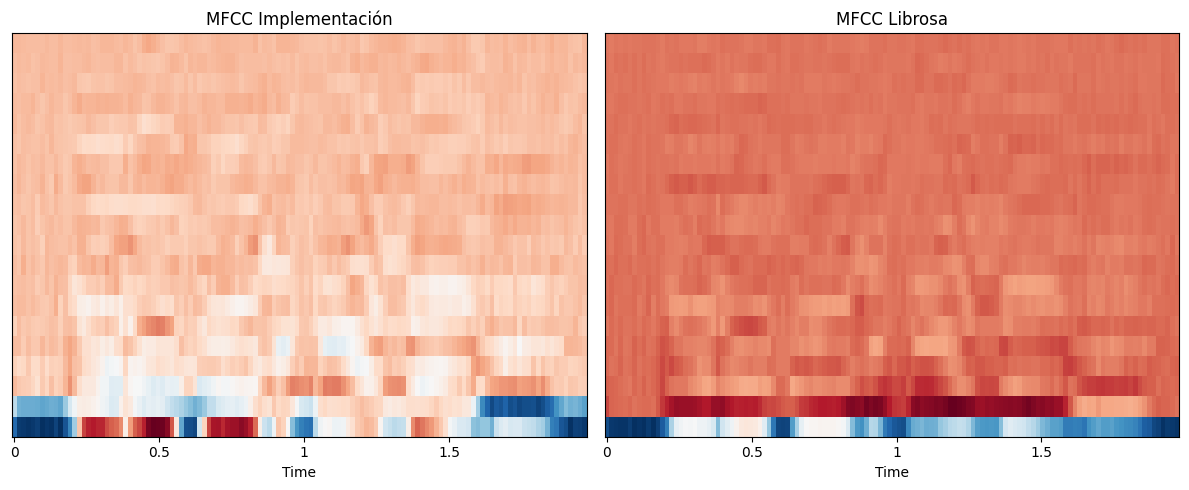

Audio: 10
Error promedio((diferencia promedio entre coeficientes MFCC (sin unidades)):  12.50173124437417


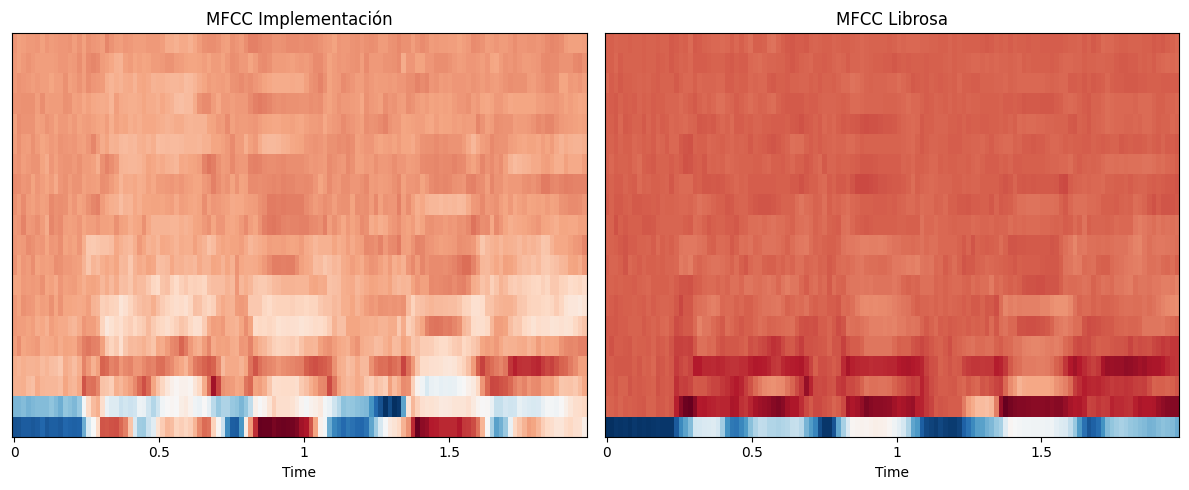

Audio: 11
Error promedio((diferencia promedio entre coeficientes MFCC (sin unidades)):  13.799545698795752


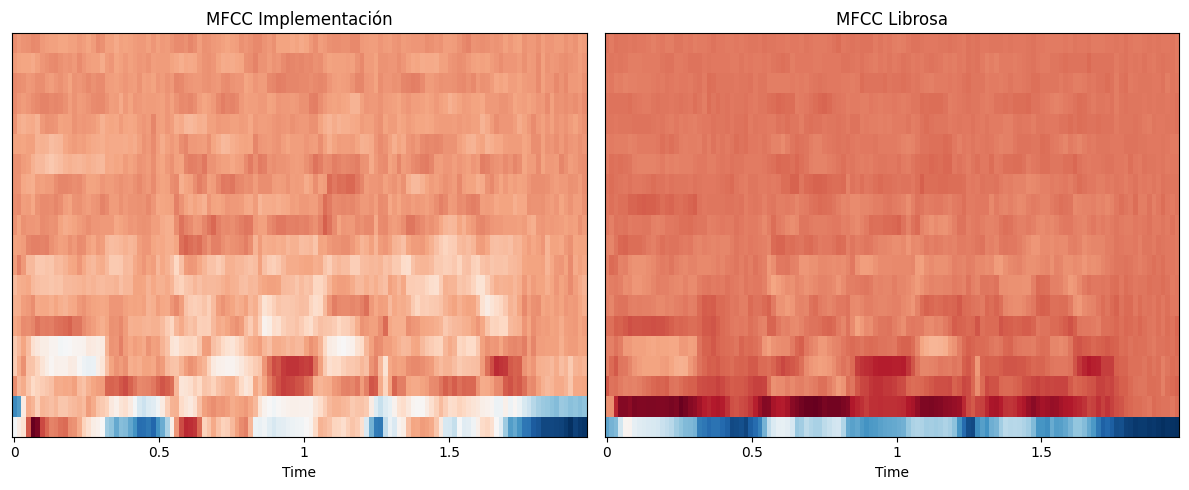

Audio: 12
Error promedio((diferencia promedio entre coeficientes MFCC (sin unidades)):  12.47155748615049


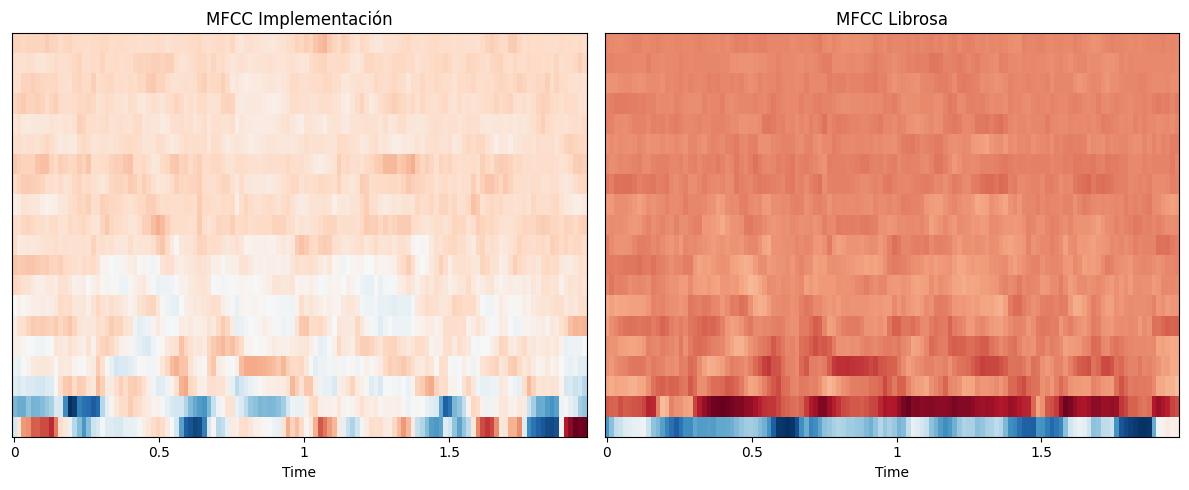

Audio: 13
Error promedio((diferencia promedio entre coeficientes MFCC (sin unidades)):  12.386901546045182


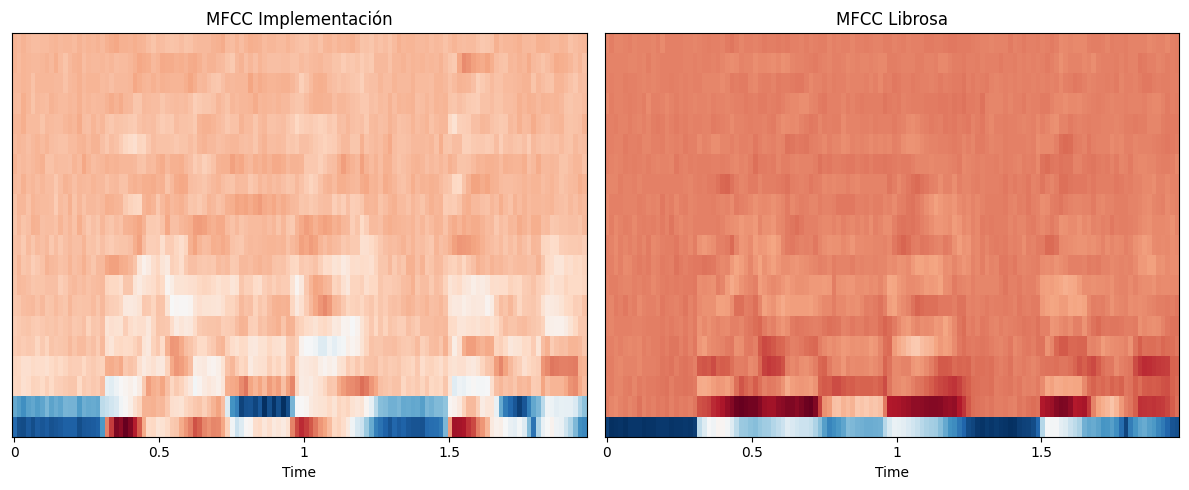

Audio: 14
Error promedio((diferencia promedio entre coeficientes MFCC (sin unidades)):  12.446767811744037


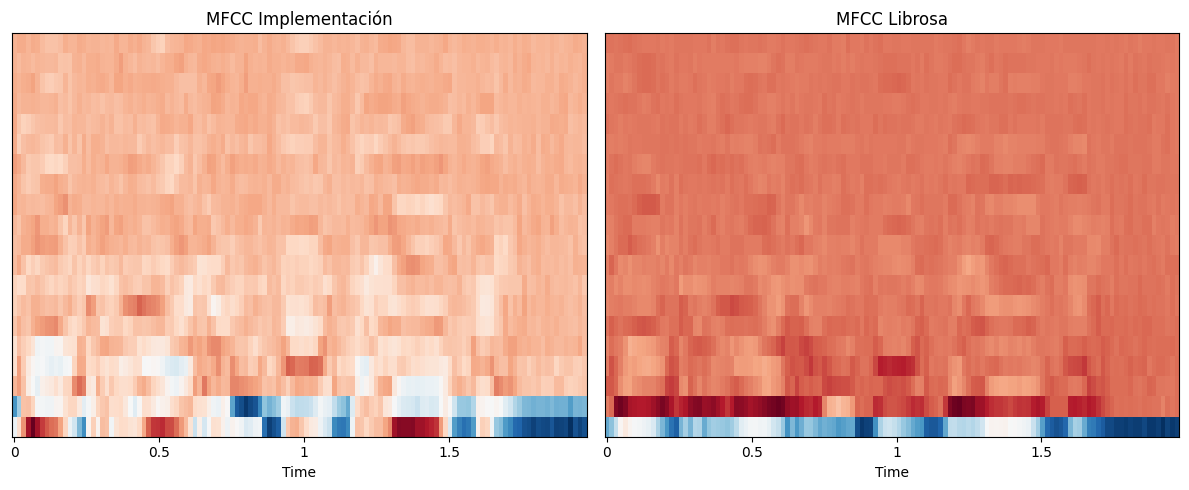


Error promedio total ): 13.053933442992754


In [22]:
import numpy as np
import matplotlib.pyplot as plt
import librosa
import librosa.display 

num_audios = 15

errores = []   #Lista para almacenar errores de cada audio

for i in range(num_audios):

    print("Audio:", i)   #Indica número de audio que se está procesando

    # MFCC de tu implementación
    mfcc_custom = trainMFCCs[i]    # ES EL MFCC CALCULADO CON TU IMPLEMENTACIÓN, NO EL DE LIBROSA

    # MFCC de librosa
    mfcc_lib = librosa.feature.mfcc(
        y=trainAudios[i],
        sr=sampling_rate,
        n_mfcc=Mel_bands,
        hop_length=Size_off,
        n_fft=Size_win,
        n_mels=Mel_bands,
        center=False
    )

    # Igualar tamaños por seguridad
    min_frames = min(mfcc_custom.shape[1], mfcc_lib.shape[1])

    mfcc_custom = mfcc_custom[:, :min_frames]
    mfcc_lib = mfcc_lib[:, :min_frames]

    # Error absoluto promedio
    error = np.mean(np.abs(mfcc_custom - mfcc_lib))   #CALCULA HACIENDO LA MEDIA DE LA DIFERENCIA ABSOLUTA ENTRE LOS DOS MFCCs
    errores.append(error)

    print("Error promedio((diferencia promedio entre coeficientes MFCC (sin unidades)): ", error)

    # ----------- GRAFICA COMPARATIVA -----------

    plt.figure(figsize=(12,5))

    plt.subplot(1,2,1)
    librosa.display.specshow(mfcc_custom,
                             sr=sampling_rate,
                             hop_length=Size_off,
                             x_axis='time',
                             cmap='RdBu_r')
    plt.title("MFCC Implementación")

    plt.subplot(1,2,2)
    librosa.display.specshow(mfcc_lib,
                             sr=sampling_rate,
                             hop_length=Size_off,
                             x_axis='time',
                             cmap='RdBu_r')
    plt.title("MFCC Librosa")

    plt.tight_layout()
    plt.show()

print("\nError promedio total ):", np.mean(errores))

###  MFCC_LightCNN - Arquitectura

Se implementó una red neuronal convolucional ligera inspirada en LightCNN.
La arquitectura está compuesta por dos bloques convolucionales seguidos de capas densas para clasificación binaria.
La red recibe como entrada coeficientes MFCC extraídos de segmentos de audio de 2 segundos.
El modelo contiene aproximadamente 21,697 parámetros entrenables, lo cual permite su implementación en dispositivos embebidos como el ESP32.

______________________________

### Qué tiene de LightCNN

LightCNN original usa tres ideas principales:

1️⃣ Bloques convolucionales pequeños

2️⃣ Pocas capas totalmente conectadas
✔ usamos solo 2 Dense

3️⃣ Red ligera (pocos parámetros)
✔ 21k es extremadamente ligero

4️⃣ Estructura de bloques CNN antes del embedding

| LightCNN9          | MFCC-LightCNN          |
| ------------------ | ------------------ |
| Conv blocks        | Conv blocks        |
| Pooling            | Pooling            |
| Feature extraction | Feature extraction |
| Embedding layer    | Dense 32           |
| Classifier         | Dense + sigmoid    |

____________________________

### Diferencia con LightCNN real

LightCNN usa:

MFM (Max Feature Map)

en lugar de:

ReLU

Pero eso es completamente justificable porque:

MFM no está soportado directamente en TensorFlow Lite Micro

ReLU reduce costo computacional y es más compatible con ESP32

| LightCNN              | MFCC-LightCNN      |
| --------------------- | ------------- |
| MFM activation        | ReLU          |
| 9 capas profundas     | 3 conv        |
| muchos filtros        | pocos filtros |
| pensado para imágenes | MFCC          |


--------------------------

Input (MFCC 20x124x1)

Conv2D 32
MaxPool

Conv2D 16
Conv2D 16
MaxPool

Flatten

Dense 32
Dropout

Dense 32
Dropout

Sigmoid

In [24]:
from keras.optimizers import Adam
from keras.optimizers import SGD
from keras.optimizers import RMSprop
from tensorflow.python.framework.convert_to_constants import convert_variables_to_constants_v2
import pandas as pd
from sklearn.metrics import precision_recall_fscore_support


#Instancia modelo con arquitectura de la red
model = tf.keras.models.Sequential([

  # ---------- LightCNN Inspired Block 1 ----------
  tf.keras.layers.Conv2D(
      32, (3,3),
      padding='same',
      strides=1,
      activation='relu',
      kernel_regularizer=l2(0.57),
      input_shape=(trainMFCCs.shape[1], trainMFCCs.shape[2], 1)
  ),

  tf.keras.layers.MaxPooling2D(3,3),

  # ---------- LightCNN Inspired Block 2 ----------
  tf.keras.layers.Conv2D(
      16, (3,3),
      padding='same',
      strides=1,
      activation='relu'
  ),

  tf.keras.layers.Conv2D(
      16, (3,3),
      padding='same',
      strides=1,
      activation='relu'
  ),

  tf.keras.layers.MaxPooling2D(3,3),

  # ---------- Embedding Layer (similar a LightCNN) ----------
  tf.keras.layers.Flatten(),

  tf.keras.layers.Dense(
      32,
      activation='relu',
      kernel_regularizer=l2(0.57)
  ),

  # ---------- Classification Head ----------
  tf.keras.layers.Dropout(0.36),

  tf.keras.layers.Dense(
      32,
      activation='relu'
  ),

  tf.keras.layers.Dropout(0.36),

  tf.keras.layers.Dense(
      1,
      activation='sigmoid'
  )
])



#Compila el modelo
new_learning_rate = 0.00047
optimizer = Adam(learning_rate=new_learning_rate)
model.compile(optimizer=optimizer, loss='binary_crossentropy', metrics=['accuracy'])


#Imprime un resumen del modelo
model.summary()


# Obtener el input shape del modelo y establecer el batch_size a 1.
# model.input_shape suele ser algo como (None, height, width, channels)
concrete_input_shape = [1] + list(model.input_shape[1:])

# Crear una función tf.function para el forward pass
run_model = tf.function(lambda x: model(x))

# Obtener la función concreta utilizando el input_shape derivado del modelo
concrete_func = run_model.get_concrete_function(tf.TensorSpec(concrete_input_shape, tf.float32))

# Convertir el modelo a un grafo congelado
frozen_func = convert_variables_to_constants_v2(concrete_func)
graph_def = frozen_func.graph.as_graph_def()

# Usar el profiler de TensorFlow para calcular los FLOPS.
with tf.compat.v1.Session() as sess:
    tf.import_graph_def(graph_def, name='')
    options = tf.compat.v1.profiler.ProfileOptionBuilder.float_operation()
    flops_profile = tf.compat.v1.profiler.profile(sess.graph, options=options)
    
    total_flops = flops_profile.total_float_ops
    print("FLOPS:", total_flops)  

Model: "sequential_1"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 conv2d_3 (Conv2D)           (None, 20, 124, 32)       320       
                                                                 
 max_pooling2d_2 (MaxPooling  (None, 6, 41, 32)        0         
 2D)                                                             
                                                                 
 conv2d_4 (Conv2D)           (None, 6, 41, 16)         4624      
                                                                 
 conv2d_5 (Conv2D)           (None, 6, 41, 16)         2320      
                                                                 
 max_pooling2d_3 (MaxPooling  (None, 2, 13, 16)        0         
 2D)                                                             
                                                                 
 flatten_1 (Flatten)         (None, 416)              

In [25]:
model.summary()

Model: "sequential_1"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 conv2d_3 (Conv2D)           (None, 20, 124, 32)       320       
                                                                 
 max_pooling2d_2 (MaxPooling  (None, 6, 41, 32)        0         
 2D)                                                             
                                                                 
 conv2d_4 (Conv2D)           (None, 6, 41, 16)         4624      
                                                                 
 conv2d_5 (Conv2D)           (None, 6, 41, 16)         2320      
                                                                 
 max_pooling2d_3 (MaxPooling  (None, 2, 13, 16)        0         
 2D)                                                             
                                                                 
 flatten_1 (Flatten)         (None, 416)              

El número de parámetros aumentó de 15553(miniVGG) a 21697 debido a la modificación de la representación de entrada MFCC y a ajustes arquitectónicos. A pesar de este aumento, el modelo sigue siendo ligero y adecuado para la inferencia en sistemas embebidos.

### MFCC_CNN - Entrenamiento

In [26]:
from keras.callbacks import ModelCheckpoint

epochs=150
# Crear ModelCheckpoint callback
model_checkpoint = ModelCheckpoint('best_model_checkpoint/best_model_epoch_{epoch:02d}.h5', monitor='val_loss', save_best_only=True, 
                                   save_weights_only=False, mode='min', verbose=1)
# Luego ejecutas model.fit
history = model.fit(trainMFCCs, trainLabels, validation_data=(evalMFCCs, evalLabels), 
                    epochs=epochs, batch_size=32, verbose=2, callbacks=[model_checkpoint])

Epoch 1/150

Epoch 1: val_loss improved from inf to 0.77293, saving model to best_model_checkpoint\best_model_epoch_01.h5
375/375 - 5s - loss: 7.6672 - accuracy: 0.5507 - val_loss: 0.7729 - val_accuracy: 0.5700 - 5s/epoch - 15ms/step
Epoch 2/150

Epoch 2: val_loss improved from 0.77293 to 0.61735, saving model to best_model_checkpoint\best_model_epoch_02.h5
375/375 - 5s - loss: 0.6706 - accuracy: 0.6585 - val_loss: 0.6174 - val_accuracy: 0.6800 - 5s/epoch - 13ms/step
Epoch 3/150

Epoch 3: val_loss improved from 0.61735 to 0.59366, saving model to best_model_checkpoint\best_model_epoch_03.h5
375/375 - 5s - loss: 0.6335 - accuracy: 0.6914 - val_loss: 0.5937 - val_accuracy: 0.7387 - 5s/epoch - 12ms/step
Epoch 4/150

Epoch 4: val_loss improved from 0.59366 to 0.59118, saving model to best_model_checkpoint\best_model_epoch_04.h5
375/375 - 5s - loss: 0.6156 - accuracy: 0.7014 - val_loss: 0.5912 - val_accuracy: 0.7088 - 5s/epoch - 13ms/step
Epoch 5/150

Epoch 5: val_loss improved from 0.59118

### MFCC_CNN - Metricas de Clasificacion y de consumo de recursos

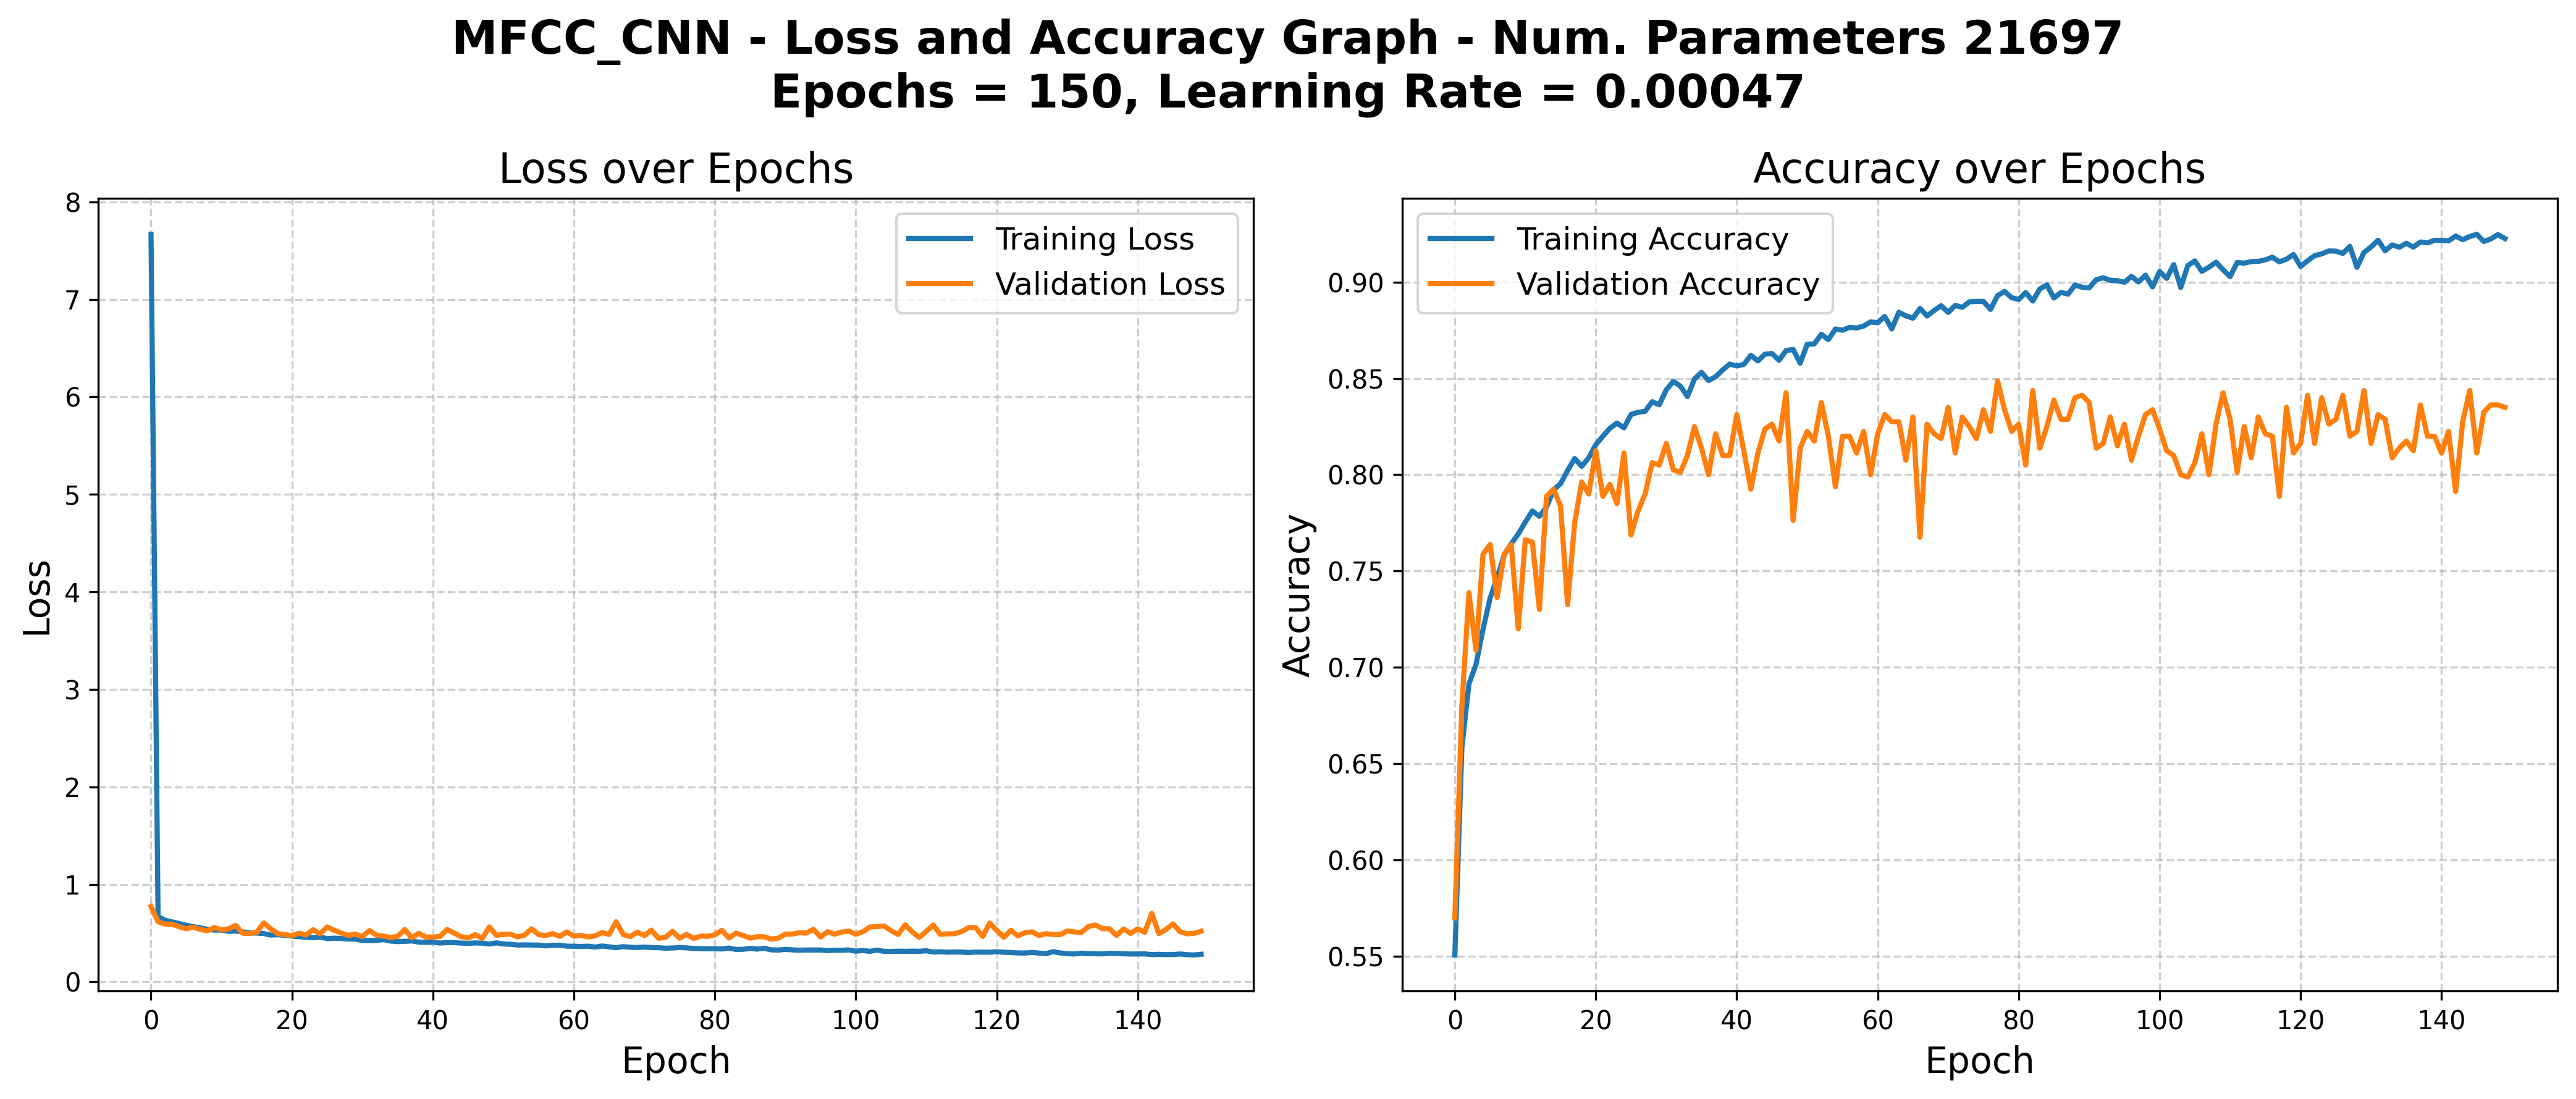

In [27]:
loss = history.history['loss']
val_loss = history.history['val_loss']
accuracy = history.history['accuracy']
val_accuracy = history.history['val_accuracy']

# Crear figura con mayor calidad
fig, axes = plt.subplots(1, 2, figsize=(14, 6), dpi=300)

# Gráfico de pérdida (Loss)
axes[0].plot(loss, label='Training Loss', linewidth=2)
axes[0].plot(val_loss, label='Validation Loss', linewidth=2)
axes[0].set_xlabel('Epoch', fontsize=14)
axes[0].set_ylabel('Loss', fontsize=14)
axes[0].set_title('Loss over Epochs', fontsize=16)
axes[0].legend(fontsize=12)
axes[0].grid(True, linestyle="--", alpha=0.6)

# Gráfico de precisión (Accuracy)
axes[1].plot(accuracy, label='Training Accuracy', linewidth=2)
axes[1].plot(val_accuracy, label='Validation Accuracy', linewidth=2)
axes[1].set_xlabel('Epoch', fontsize=14)
axes[1].set_ylabel('Accuracy', fontsize=14)
axes[1].set_title('Accuracy over Epochs', fontsize=16)
axes[1].legend(fontsize=12)
axes[1].grid(True, linestyle="--", alpha=0.6)

# Título general con más claridad
plt.suptitle(f"MFCC_CNN - Loss and Accuracy Graph - Num. Parameters {model.count_params()}\n"
             f"Epochs = {epochs}, Learning Rate = {new_learning_rate}",
             fontsize=18, fontweight='bold')

# Ajuste automático para evitar superposiciones
plt.tight_layout()

# Guardar la imagen en alta calidad
plt.savefig("training_metrics.png", dpi=300, bbox_inches="tight", format="png")

# Mostrar la gráfica
plt.show()

In [28]:
#Carga Mejor modelo
from keras.models import load_model
# Cargar el modelo guardado en "best_model.h5"
model = load_model('best_model_checkpoint/best_model_epoch_89.h5')

# Evaluación en el conjunto test
_, accuracy = model.evaluate(testMFCCs, testLabels)
print(f'Accuracy: {accuracy}')

38/38 [==============================] - 0s 5ms/step - loss: 0.4422 - accuracy: 0.8467
Accuracy: 0.846666693687439


In [29]:
# Evaluación en el conjunto train
_, accuracy = model.evaluate(trainMFCCs, trainLabels)
print(f'Accuracy: {accuracy}')

375/375 [==============================] - 2s 5ms/step - loss: 0.2833 - accuracy: 0.9152
Accuracy: 0.9151666760444641


### Exporta Modelo

In [30]:
#Exporta el modelo
export_dir = 'CNN_Python/saved_models/ModelMFCC_Light_CNN'
tf.saved_model.save(model, export_dir)
tf.keras.models.save_model(model, export_dir)

export_dir = 'saved_models/ModelMFCC_Light_CNN/ModelMFCC_Light_CNN.keras'
tf.keras.models.save_model(model, export_dir)

INFO:tensorflow:Assets written to: CNN_Python/saved_models/ModelMFCC_Light_CNN\assets


INFO:tensorflow:Assets written to: CNN_Python/saved_models/ModelMFCC_Light_CNN\assets


INFO:tensorflow:Assets written to: CNN_Python/saved_models/ModelMFCC_Light_CNN\assets


INFO:tensorflow:Assets written to: CNN_Python/saved_models/ModelMFCC_Light_CNN\assets


### Pruebas

In [ ]:
#Define Umbral
umbral = 0.9
#Predice probabilidades de las clases (de 0 a 1)
predict = model.predict(evalMFCCs)
# Aplica el umbral para convertir las predicciones en 0 o 1
Label_predict = (predict > umbral).astype(int)
#Dimenciones de vector de etiquetas
print("Dimensiones de vector de etiquetas: ", Label_predict.shape)

25/25 [==============================] - 0s 6ms/step
Dimensiones de vector de etiquetas:  (800, 1)


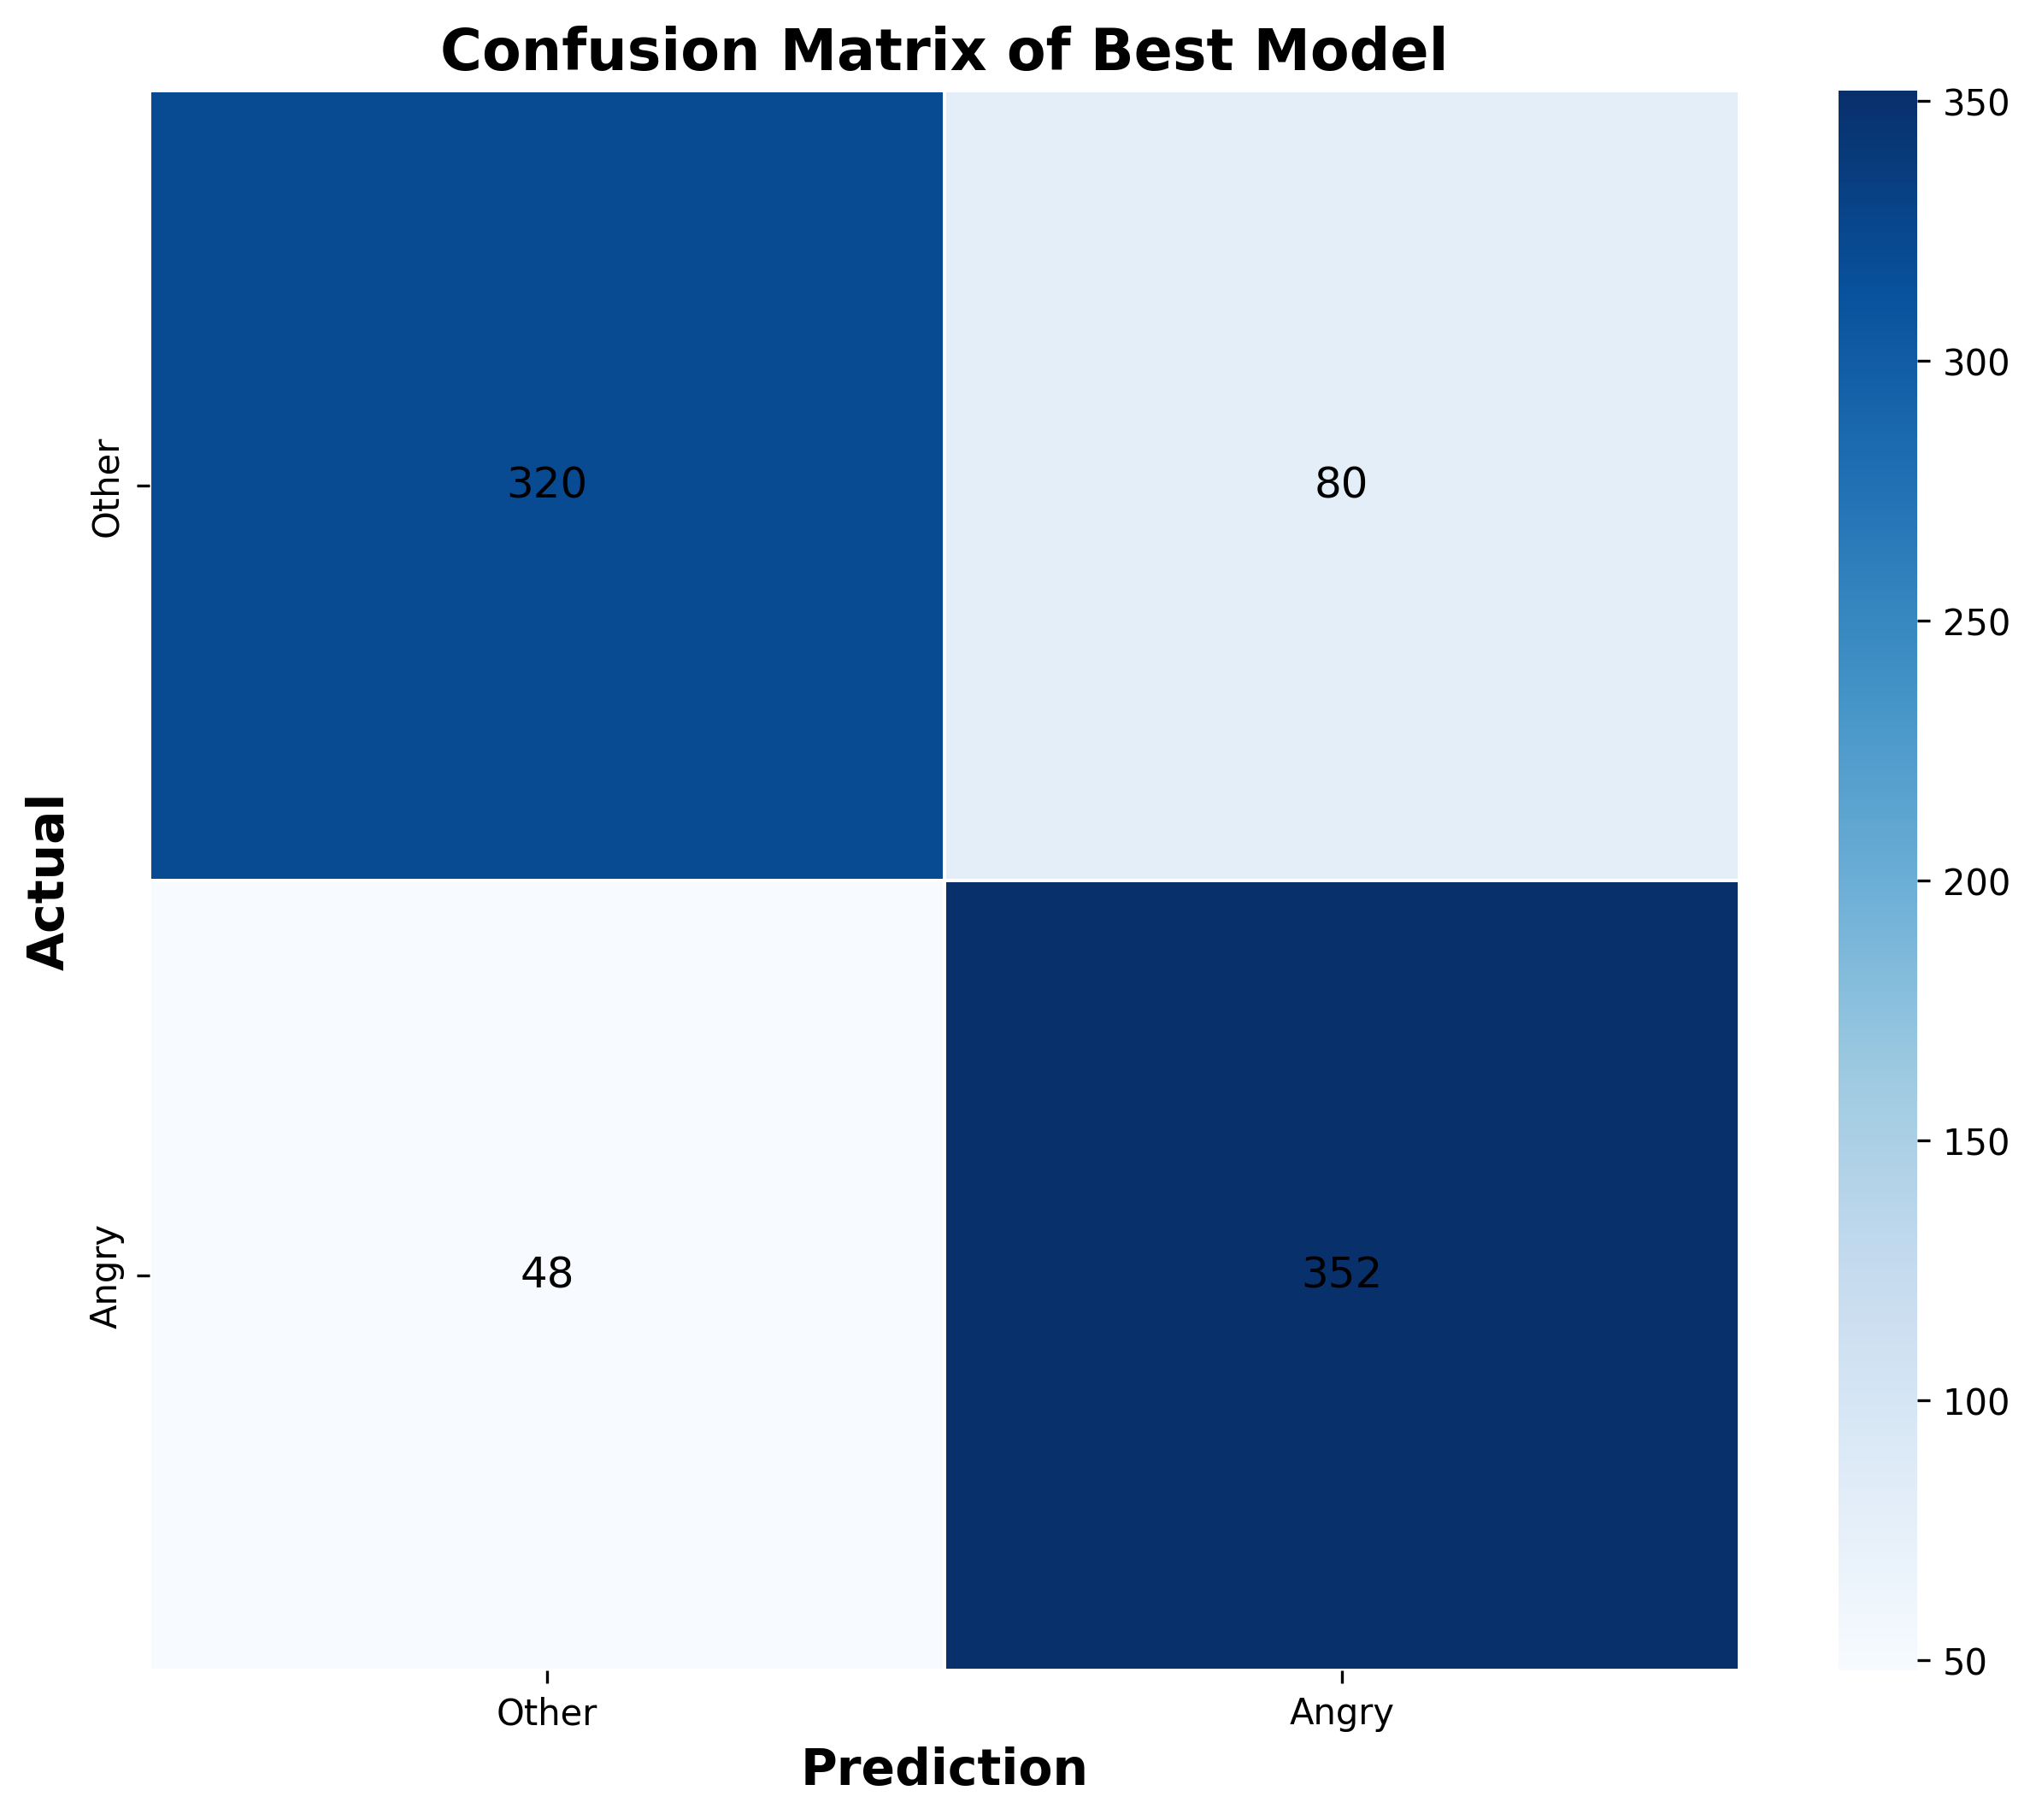

In [33]:
#Calcula matriz de confusión
con_mat = confusion_matrix(evalLabels, Label_predict, labels=clases_vec)
#Convierte matriz en un pandas dataframe
#Rows =    Valores verdaderos
#Columns = Valores predichos
con_mat_df = pd.DataFrame(con_mat, index=emotion_vec, columns=emotion_vec)

# Crear un mapa de calor con mayor calidad
plt.figure(figsize=(10, 8), dpi=300)
sns.heatmap(con_mat_df, annot=True, fmt='d', cmap='Blues', 
            linewidths=0.5, annot_kws={'size': 12, 'color': 'black'})

# Etiquetas y título mejorados
plt.xlabel('Prediction', fontsize=14, fontweight='bold')
plt.ylabel('Actual', fontsize=14, fontweight='bold')
plt.title('Confusion Matrix of Best Model', fontsize=16, fontweight='bold')

# Mostrar la gráfica
plt.show()

In [34]:
# Evaluación en el conjunto de validación
_, accuracy = model.evaluate(evalMFCCs, evalLabels)

print(f'Accuracy: {accuracy}')

25/25 [==============================] - 0s 6ms/step - loss: 0.4396 - accuracy: 0.8400
Accuracy: 0.8399999737739563


In [35]:
import pandas as pd
from sklearn.metrics import precision_recall_fscore_support

# Assume you have defined your MiniVGG16 model and it's stored in the variable `model`
# model = MiniVGG16(...) 


# Calculate the total number of parameters in the model
total_params = model.count_params()

# Heuristic to determine computational complexity based on parameter count
if total_params < 1e6:
    model_complexity = "Baja"   # Low complexity
elif total_params < 1e7:
    model_complexity = "Media"  # Medium complexity
else:
    model_complexity = "Alta"   # High complexity

# Define model name
model_name = "MFCC_Light_CNN"

# Crea lista vacía de estadísticos
statistics = []

# Ciclo para calcular especificidad, recall, precision y f_score
for label in range(0, 2):
    precision, recall, f_score, support = precision_recall_fscore_support(
        evalLabels == label,
        Label_predict == label
    )
    # Se añade a cada registro:
    # [Nombre del modelo, emoción, especificidad, recall, precision, f_score, FLOPS, complejidad computacional]
    statistics.append([
        model_name,
        emotion_vec[label],
        recall[0],
        recall[1],
        precision[1],
        f_score[1],
        total_flops,
        model_complexity
    ])

# Convierte resultados en dataframe y agrega columnas
statistics = pd.DataFrame(statistics, columns=[
    "Model", "Emotion", "Specificity", "Recall", "Precision", "F_Score", "FLOPS", "Comp_Complexity"
])
statistics

#Ciclo para calcular especificidad, recall, precision y f_score
#for label in range(0,2):
#    precision, recall, f_score, support = precision_recall_fscore_support(evalLabels==label,
#                                           Label_predict==label)
#    statistics.append([emotion_vec[label], recall[0], recall[1], precision[1], f_score[1]])

#Convierte resultados en dataframe y agrega columnas
#statistics = pd.DataFrame(statistics, columns=["Emotion","Specificity", "Recall", "Precision", "F_Score"])
#statistics

,Model,Emotion,Specificity,Recall,Precision,F_Score,FLOPS,Comp_Complexity
0,MFCC_Light_CNN,Other,0.88,0.80,0.869565,0.833333,10039618,Baja
1,MFCC_Light_CNN,Angry,0.80,0.88,0.814815,0.846154,10039618,Baja


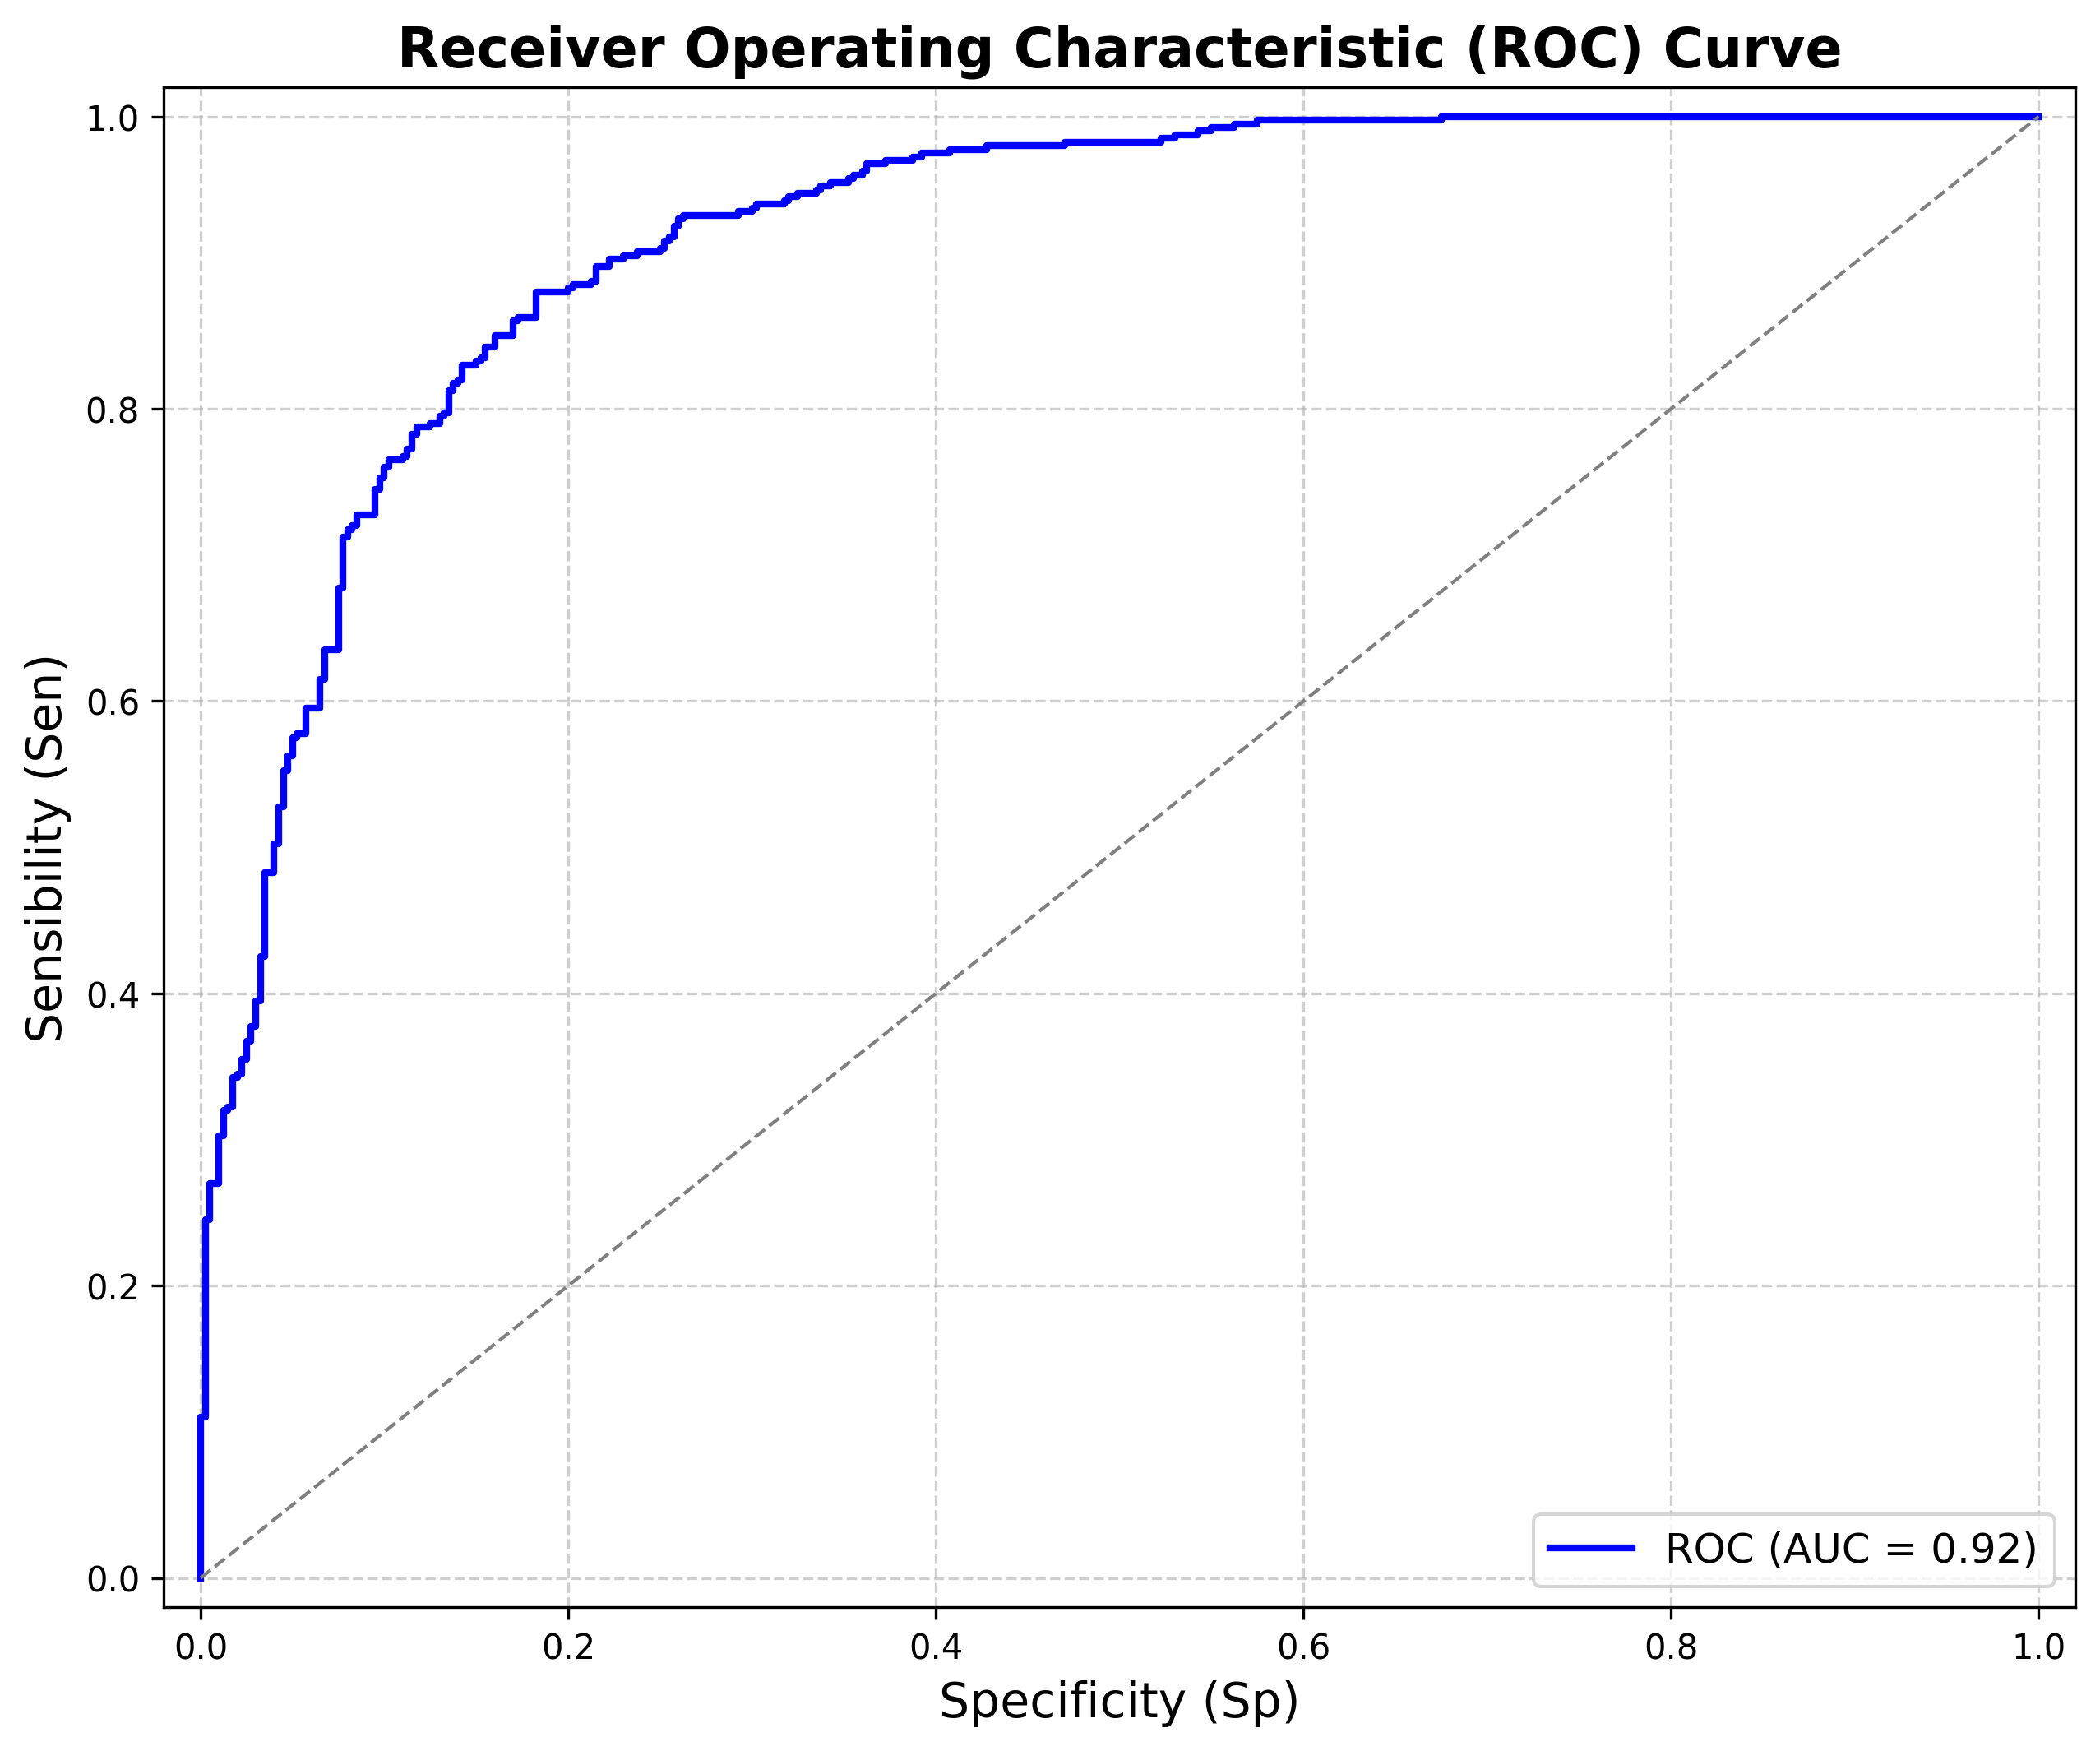

In [36]:
# Supongamos que 'etiquetas_reales' son las etiquetas reales (0 o 1) y 'predicciones' son las predicciones del modelo.
# Asegúrate de tener predicciones continuas (no binarias) en 'predicciones'.

fpr, tpr, umbrales = roc_curve(evalLabels, predict)
area_bajo_curva = roc_auc_score(evalLabels, predict)

# Mejora la calidad de la imagen
plt.figure(figsize=(10, 8), dpi=300)

# Graficar la Curva ROC
plt.plot(fpr, tpr, color='blue', lw=2, label=f'ROC (AUC = {area_bajo_curva:.2f})')
plt.plot([0, 1], [0, 1], color='gray', linestyle='--', lw=1)  # Línea de referencia

# Configuración de ejes y estilo
plt.xlim([-0.02, 1.02])
plt.ylim([-0.02, 1.02])
plt.xlabel('Specificity (Sp)', fontsize=14)
plt.ylabel('Sensibility (Sen)', fontsize=14)
plt.title('Receiver Operating Characteristic (ROC) Curve', fontsize=16, fontweight='bold')

# Agregar cuadrícula
plt.grid(True, linestyle='--', alpha=0.6)

# Mostrar leyenda
plt.legend(loc='lower right', fontsize=12)

# Mostrar la gráfica
plt.show()

# TENSORFLOW LITE

### Convierte Modelo

In [37]:
#Path del modelo
model_dir = 'saved_models/ModelMFCC_Light_CNN'

In [39]:
#Convierte el modelo con tensorflow lite desde un modelo guardado
converter = tf.lite.TFLiteConverter.from_saved_model(model_dir)
#Guarda modelo en variable
tflite_model = converter.convert()

In [40]:
#imprime tamaño del modelo en bytes
tflite_model_file = pathlib.Path('ModelMFCC_Light_CNN.tflite')
#Escribe bytes del archivo
tflite_model_file.write_bytes(tflite_model)

91200

### Carga Modelo

In [41]:
# Load TFLite model and allocate tensors.
tflite_model_file = 'ModelMFCC_Light_CNN.tflite'
interpreter = tf.lite.Interpreter(model_path=tflite_model_file)
interpreter.allocate_tensors()

#Obtiene los índices de entrada y salida
input_index = interpreter.get_input_details()[0]["index"]
output_index = interpreter.get_output_details()[0]["index"]

In [42]:
# Obtener todos los detalles del modelo
model_details = interpreter.get_tensor_details()

# Filtrar los detalles para obtener solo los relacionados con los parámetros
parameter_details = [detail for detail in model_details if 'weight' in detail['name'] or 'bias' in detail['name']]

# Calcular el número total de parámetros
total_parameters = sum(np.prod(detail['shape']) for detail in parameter_details)

print("Número total de parámetros:", total_parameters)

Número total de parámetros: 7200


Convertir a INT8

In [ ]:
converter = tf.lite.TFLiteConverter.from_keras_model(model)

converter.optimizations = [tf.lite.Optimize.DEFAULT]

def representative_data_gen():
    for i in range(100):
        data = trainMFCCs[i]
        data = np.expand_dims(data, axis=0)
        yield [data.astype(np.float32)]

converter.representative_dataset = representative_data_gen

converter.target_spec.supported_ops = [tf.lite.OpsSet.TFLITE_BUILTINS_INT8]

converter.inference_input_type = tf.int8
converter.inference_output_type = tf.int8

tflite_model = converter.convert()

with open("ModelMFCC_Light_CNN.tflite", "wb") as f:
    f.write(tflite_model)

INFO:tensorflow:Assets written to: C:\Users\EALO4\AppData\Local\Temp\tmp0mgico4s\assets


INFO:tensorflow:Assets written to: C:\Users\EALO4\AppData\Local\Temp\tmp0mgico4s\assets
c:\Users\EALO4\AppData\Local\Programs\Python\Python310\lib\site-packages\tensorflow\lite\python\convert.py:789: UserWarning: Statistics for quantized inputs were expected, but not specified; continuing anyway.
  warnings.warn("Statistics for quantized inputs were expected, but not "


Detalles

In [93]:
interpreter.get_input_details()

[{'name': 'serving_default_conv2d_input:0',
  'index': 0,
  'shape': array([  1,  20, 124,   1]),
  'shape_signature': array([ -1,  20, 124,   1]),
  'dtype': numpy.float32,
  'quantization': (0.0, 0),
  'quantization_parameters': {'scales': array([], dtype=float32),
   'zero_points': array([], dtype=int32),
   'quantized_dimension': 0},
  'sparsity_parameters': {}}]

In [94]:
interpreter.get_output_details()

[{'name': 'StatefulPartitionedCall:0',
  'index': 23,
  'shape': array([1, 1]),
  'shape_signature': array([-1,  1]),
  'dtype': numpy.float32,
  'quantization': (0.0, 0),
  'quantization_parameters': {'scales': array([], dtype=float32),
   'zero_points': array([], dtype=int32),
   'quantized_dimension': 0},
  'sparsity_parameters': {}}]

Convertir tflites a .cc

In [43]:
with open("ModelMFCC_Light_CNN.tflite", "rb") as f:
#with open("model_int8.tflite", "rb") as f:

    data = f.read()

with open("model_data.cc", "w") as f:
    f.write("alignas(16) const unsigned char g_model[] = {\n")
    
    for i, b in enumerate(data):
        if i % 12 == 0:
            f.write("\n ")
        f.write(f"0x{b:02x}, ")
    
    f.write("\n};\n")
    f.write(f"const int g_model_len = {len(data)};\n")

## Predicciones

### Entrenamiento

In [44]:
#Agrega dimensión para que coincida con la entrada de la red
trainMFCCs = np.expand_dims(trainMFCCs, axis=-1)
trainMFCCs = trainMFCCs.astype(np.float32)

#Predicciones de entrenamiento
predictions = []
for mfcc in trainMFCCs:
    # Asegúrate de que 'mfcc' tenga la forma y tipo de datos correctos
    mfcc = np.expand_dims(mfcc, axis=0).astype(np.float32)
    
    # Establecer la entrada del modelo
    interpreter.set_tensor(input_index, mfcc)
    
    # Realizar la inferencia
    interpreter.invoke()
    
    # Obtener la salida del modelo
    output = interpreter.get_tensor(output_index)
    predictions.append(output)

In [45]:
predictions[0:10]

[array([[0.18733025]], dtype=float32),
 array([[0.9634684]], dtype=float32),
 array([[0.9164216]], dtype=float32),
 array([[0.91372657]], dtype=float32),
 array([[0.20865613]], dtype=float32),
 array([[0.92705184]], dtype=float32),
 array([[0.9103539]], dtype=float32),
 array([[0.7585237]], dtype=float32),
 array([[0.95186585]], dtype=float32),
 array([[0.9204241]], dtype=float32)]

In [46]:
umbral = 0.5
predictions = np.array(predictions).squeeze()  # Convertir la lista a un array
predicted_labels = (predictions > umbral).astype(int)  # Usar un umbral si es necesario

# Comparar con las etiquetas reales
accuracy = np.mean(predicted_labels == trainLabels)
print("Precisión del modelo:", accuracy)

Precisión del modelo: 0.9151666666666667


### Prueba

In [47]:
#Agrega dimensión para que coincida con la entrada de la red
testMFCCs = np.expand_dims(testMFCCs, axis=-1)
testMFCCs = testMFCCs.astype(np.float32)

#Predicciones de entrenamiento
predictions = []
for mfcc in testMFCCs:
    # Asegúrate de que 'mfcc' tenga la forma y tipo de datos correctos
    mfcc = np.expand_dims(mfcc, axis=0).astype(np.float32)
    
    # Establecer la entrada del modelo
    interpreter.set_tensor(input_index, mfcc)
    
    # Realizar la inferencia
    interpreter.invoke()
    
    # Obtener la salida del modelo
    output = interpreter.get_tensor(output_index)
    predictions.append(output)

#Calcula precisión según umbral
umbral = 0.5
predictions = np.array(predictions).squeeze()  # Convertir la lista a un array
predicted_labels = (predictions > umbral).astype(int)  # Usar un umbral si es necesario

# Comparar con las etiquetas reales
accuracy = np.mean(predicted_labels == testLabels)
print("Precisión del modelo:", accuracy)

Precisión del modelo: 0.8466666666666667


### Evaluación

In [48]:
#Agrega dimensión para que coincida con la entrada de la red
evalMFCCs = np.expand_dims(evalMFCCs, axis=-1)
evalMFCCs = evalMFCCs.astype(np.float32)

#Predicciones de entrenamiento
predictions = []
for mfcc in evalMFCCs:
    # Asegúrate de que 'mfcc' tenga la forma y tipo de datos correctos
    mfcc = np.expand_dims(mfcc, axis=0).astype(np.float32)
    
    # Establecer la entrada del modelo
    interpreter.set_tensor(input_index, mfcc)
    
    # Realizar la inferencia
    interpreter.invoke()
    
    # Obtener la salida del modelo
    output = interpreter.get_tensor(output_index)
    predictions.append(output)

#Calcula precisión según umbral
umbral = 0.5
predictions = np.array(predictions).squeeze()  # Convertir la lista a un array
predicted_labels = (predictions > umbral).astype(int)  # Usar un umbral si es necesario

# Comparar con las etiquetas reales
accuracy = np.mean(predicted_labels == evalLabels)
print("Precisión del modelo:", accuracy)

Precisión del modelo: 0.84


### Matriz de confusión

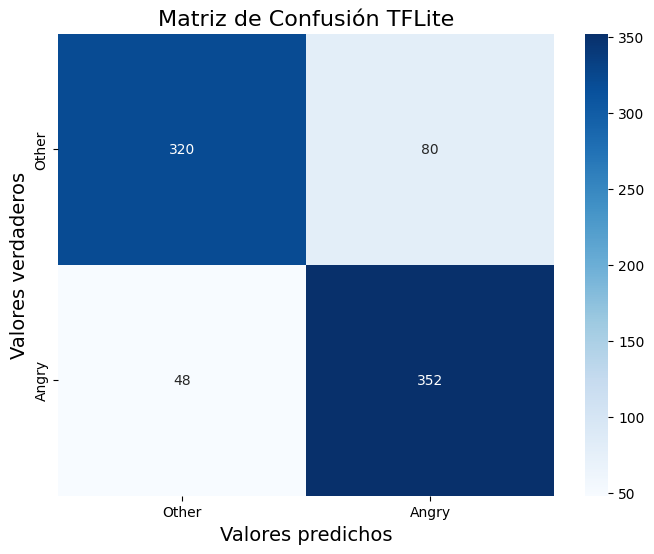

In [49]:
#Predicciones de 0 y 1
predictions_bin = (predictions > umbral).astype(int)

#Vector de clases
clases_vec = [0,1]
emotion_vec = ["Other","Angry"]

#Calcula matriz de confusión
con_mat = confusion_matrix(evalLabels, predictions_bin, labels=clases_vec)
#Convierte matriz en un pandas dataframe
#Rows =    Valores verdaderos
#Columns = Valores predichos
con_mat_df = pd.DataFrame(con_mat, index=emotion_vec, columns=emotion_vec)

# Crear un mapa de calor
plt.figure(figsize=(8, 6))
sns.heatmap(con_mat_df, annot=True, fmt='d', cmap='Blues')

plt.xlabel('Valores predichos', fontsize=14)
plt.ylabel('Valores verdaderos', fontsize=14)
plt.title('Matriz de Confusión TFLite', fontsize=16)
plt.show()

### Curva ROC

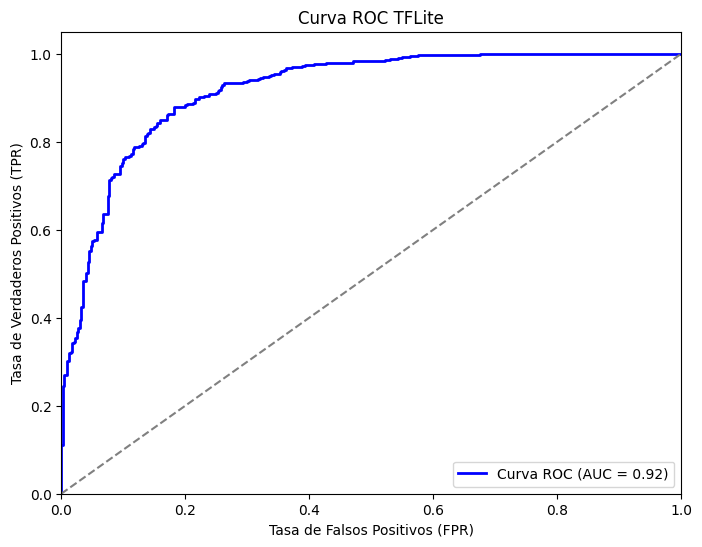

In [50]:
# Supongamos que 'etiquetas_reales' son las etiquetas reales (0 o 1) y 'predicciones' son las predicciones del modelo.
# Asegúrate de tener predicciones continuas (no binarias) en 'predicciones'.

fpr, tpr, umbrales = roc_curve(evalLabels, predictions)
area_bajo_curva = roc_auc_score(evalLabels, predictions)

# Grafica la Curva ROC
plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, color='blue', lw=2, label=f'Curva ROC (AUC = {area_bajo_curva:.2f})')
plt.plot([0, 1], [0, 1], color='gray', linestyle='--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('Tasa de Falsos Positivos (FPR)')
plt.ylabel('Tasa de Verdaderos Positivos (TPR)')
plt.title('Curva ROC TFLite')
plt.legend(loc='lower right')
plt.show()